In [28]:
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import joblib
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn import svm


import warnings
warnings.filterwarnings('ignore')

In [29]:
df = pd.read_csv('heart_cleaned.csv')
df.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,MaxHR,ExerciseAngina,Oldpeak,HeartDisease,ChestPainType_ASY,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA,RestingECG_LVH,RestingECG_Normal,RestingECG_ST,ST_Slope_Down,ST_Slope_Flat,ST_Slope_Up
0,40,1,140,289.0,0,172,0,0.0,False,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
1,49,0,160,180.0,0,156,0,1.0,True,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
2,37,1,130,283.0,0,98,0,0.0,False,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0
3,48,0,138,214.0,0,108,1,1.5,True,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,54,1,150,195.0,0,122,0,0.0,False,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0


In [30]:
class FeatureCategorizer:
    def __init__(self, df):
        self.df = df.copy()
        self.continuous_features = []
        self.binary_features = []
        
    def categorize_features(self):
        
        for col in self.df.columns:
            unique_vals = self.df[col].nunique()
            is_numeric = pd.api.types.is_numeric_dtype(self.df[col])
            unique_values = sorted(self.df[col].unique())

            if is_numeric:
                if unique_vals == 2 or set(self.df[col].unique()).issubset({0, 1, 0.0, 1.0}):
                    self.binary_features.append(col)
                else:
                    self.continuous_features.append(col)
            else:
                # Handle boolean or string binary features
                if unique_vals == 2:
                    self.binary_features.append(col)
                else:
                    print(f"  → Classified as: OTHER (will be ignored)")
        return self.continuous_features, self.binary_features
# Categorize features
categorizer = FeatureCategorizer(df)
continuous_features, binary_features = categorizer.categorize_features()

In [31]:
from sklearn.feature_selection import mutual_info_classif

X = df.drop('HeartDisease', axis=1)
Y = df['HeartDisease']

mutua_informazione_feature = []

def analyze_feature_information(X, Y, continuous_features, binary_features):
    """
    Calcola la mutual information media per feature numeriche e binarie.
    
    Args:
        X (pd.DataFrame): dataset delle feature
        y (pd.Series o array): target
        numerical_features (list): lista nomi delle feature numeriche
        binary_features (list): lista nomi delle feature binarie
    
    Returns:
        dict: valori medi di mutual information
    """
    # Calcolo mutual information per tutte le feature
    mi = mutual_info_classif(X, Y, discrete_features='auto', random_state=42)
    mi_df = pd.DataFrame({
        "feature": X.columns,
        "mutual_info": mi
    })
    
    # Separazione numeriche e binarie
    mi_numerical = mi_df[mi_df["feature"].isin(continuous_features)]["mutual_info"].mean()
    mi_binary = mi_df[mi_df["feature"].isin(binary_features)]["mutual_info"].mean()
    
    return {
        "MI_numerical": mi_numerical,
        "MI_binary": mi_binary
    }

ris = analyze_feature_information(X, Y, continuous_features, binary_features)
print(ris)

{'MI_numerical': np.float64(0.06646737346489448), 'MI_binary': np.float64(0.06725815612608918)}


In [32]:
def add_progressive_noise_to_binary_features(df: pd.DataFrame, binary_features: list, target_column: str = None) -> dict:
    """
    Aggiunge progressivamente rumore a tutte le colonne binarie (0/1) di un DataFrame.
    
    La funzione itera dal 0% al 100% con incrementi del 10%, e per ogni step
    inverte una percentuale corrispondente di TUTTI i valori binari nel dataset
    (escludendo opzionalmente la colonna target).
    
    Args:
        df (pd.DataFrame): Il DataFrame di input.
        binary_features (list): Lista delle colonne binarie da modificare 
                                (ottenuta da FeatureCategorizer).
        target_column (str, optional): Nome della colonna target da escludere.
                                       Se None, include tutte le colonne binarie.
    
    Returns:
        dict: Un dizionario di DataFrame. Le chiavi indicano la percentuale
              di rumore e i valori sono i DataFrame modificati.
    """
    # Filtra le colonne binarie escludendo la colonna target se specificata
    columns_to_noise = [col for col in binary_features if col != target_column] if target_column else binary_features
    
    if len(columns_to_noise) == 0:
        raise ValueError("Nessuna colonna binaria da modificare (tutte escluse o lista vuota).")
    
    print(f"Colonne binarie da modificare: {columns_to_noise}")
    
    noisy_datasets = {}
    
    # Calcola il numero totale di elementi binari nel dataset
    total_binary_elements = len(df) * len(columns_to_noise)
    print(f"Totale elementi binari da considerare: {total_binary_elements}")
    
    # Itera attraverso le percentuali di rumore da 0 a 100 con step di 10
    for percentage in range(0, 101, 10):
        # Lavoriamo sempre su una copia pulita del df originale
        df_noisy = df.copy()
        
        # Se la percentuale è 0, non facciamo nulla
        if percentage == 0:
            noisy_datasets[f'0%_noise'] = df_noisy
            print(f"Generato dataset con 0% di rumore (nessuna modifica).")
            continue
        
        # Calcola il numero totale di elementi da invertire
        n_to_flip = int(np.floor(total_binary_elements * (percentage / 100)))
        
        # Crea una lista di tutte le posizioni possibili (riga, colonna)
        all_positions = [(row_idx, col) for row_idx in df.index for col in columns_to_noise]
        
        # Seleziona casualmente n_to_flip posizioni da invertire
        # Usiamo random_state per riproducibilità
        np.random.seed(42)
        positions_to_flip = np.random.choice(len(all_positions), size=n_to_flip, replace=False)
        
        # Inverti i valori nelle posizioni selezionate
        for pos_idx in positions_to_flip:
            row_idx, col = all_positions[pos_idx]
            df_noisy.loc[row_idx, col] = 1 - df_noisy.loc[row_idx, col]
        
        # Salva il DataFrame rumoroso nel dizionario
        key_name = f'{percentage}%_noise'
        noisy_datasets[key_name] = df_noisy
        print(f"Generato dataset con {percentage}% di rumore ({n_to_flip} elementi binari invertiti).")
    
    return noisy_datasets

noisy_datasets = add_progressive_noise_to_binary_features(df, binary_features, target_column='HeartDisease')

Colonne binarie da modificare: ['Sex', 'FastingBS', 'ExerciseAngina', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']
Totale elementi binari da considerare: 11934
Generato dataset con 0% di rumore (nessuna modifica).
Generato dataset con 10% di rumore (1193 elementi binari invertiti).
Generato dataset con 20% di rumore (2386 elementi binari invertiti).
Generato dataset con 30% di rumore (3580 elementi binari invertiti).
Generato dataset con 40% di rumore (4773 elementi binari invertiti).
Generato dataset con 50% di rumore (5967 elementi binari invertiti).
Generato dataset con 60% di rumore (7160 elementi binari invertiti).
Generato dataset con 70% di rumore (8353 elementi binari invertiti).
Generato dataset con 80% di rumore (9547 elementi binari invertiti).
Generato dataset con 90% di rumore (10740 elementi binari invertiti).
Generato dataset con 

In [33]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

all_metrics_noisy = []

def calculate_metrics(y_test, y_pred, model_name, approach, step_idx):
    """
    Calculate metrics and return a dictionary with model info
    """
    metrics = {
        'model': model_name,
        'approach': approach,
        'step': step_idx,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1_score': f1_score(y_test, y_pred)
    }
    
    # Print metrics (to maintain your current output format)
    print(f"Misure di performance globali {model_name.lower()} {approach.lower()}\n")
    print('Accuracy:', metrics['accuracy'])
    print('Precision:', metrics['precision'])
    print('Recall:', metrics['recall'])
    print('F1-score:', metrics['f1_score'])
    
    return metrics

timing_collector_noisy= {
    'dt_naive_training': 0,
    'dt_optimal_training': 0, 
    'dt_hyperparameter': 0,
    'svm_naive_training': 0,
    'svm_optimal_training': 0,
    'svm_hyperparameter': 0,
    'nn_naive_training': 0,
    'nn_optimal_training': 0,
    'nn_hyperparameter': 0
}

PROGRESSIVE NOISE CONTAMINATION EXPERIMENT


--- INIZIO TRAINING: DECISION TREE ---
Training Decision Tree - Naive approach...
Binary columns to modify: ['Sex', 'FastingBS', 'ExerciseAngina', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']
Original DataFrame with 918 rows.
Total binary elements to consider: 11934
Generating progressively noisy datasets and training Decision Tree (Naive)...


===== Training Decision Tree (Naive) at Step 0 (Noise: 0%) =====
Generated dataset with 0% noise (no modifications).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0644
Training Decision Tree with Naive approach...
Training completed in 0.0078 seconds

RESULTS FOR STEP 0
  Binary elements flipped: 0
  Accuracy Test:   0.7772
  Accuracy Train:  1.0000
  Precision: 

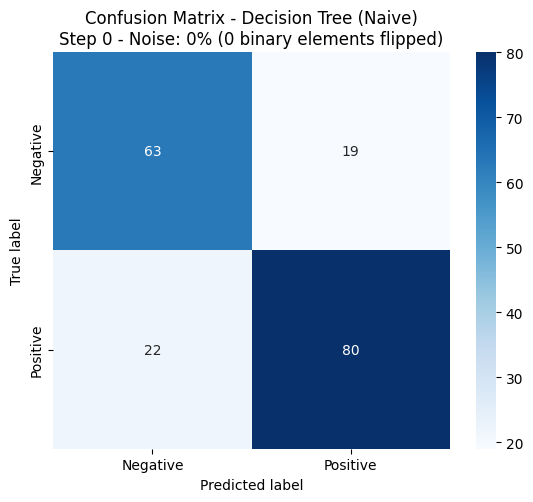

Feature Importances: [0.0756858  0.02670642 0.04393225 0.08843231 0.0116011  0.10569005
 0.00419949 0.09794859 0.08774174 0.         0.         0.00413388
 0.01653791 0.         0.00551183 0.00712641 0.00353323 0.421219  ]
✅ Step 0 completed (Noise: 0%)


===== Training Decision Tree (Naive) at Step 1 (Noise: 10%) =====
Generated dataset with 10% noise (1193 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0381
Training Decision Tree with Naive approach...
Training completed in 0.0037 seconds

RESULTS FOR STEP 1
  Binary elements flipped: 1193
  Accuracy Test:   0.7935
  Accuracy Train:  1.0000
  Precision:       0.8200
  Recall:          0.8039
  F1-score:        0.8119
  Training time:   0.0037 sec


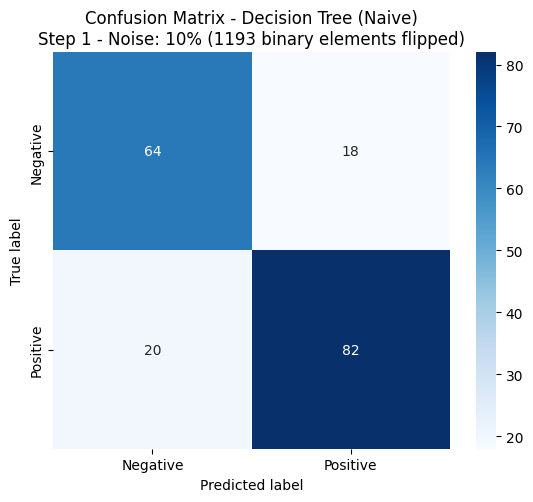

Feature Importances: [0.05399784 0.01601767 0.09436188 0.11041407 0.01781603 0.1579904
 0.00854308 0.13162296 0.04554149 0.02052816 0.01052259 0.01023626
 0.00501076 0.0094926  0.01045085 0.         0.04255577 0.25489756]
✅ Step 1 completed (Noise: 10%)


===== Training Decision Tree (Naive) at Step 2 (Noise: 20%) =====
Generated dataset with 20% noise (2386 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0264
Training Decision Tree with Naive approach...
Training completed in 0.0032 seconds

RESULTS FOR STEP 2
  Binary elements flipped: 2386
  Accuracy Test:   0.7663
  Accuracy Train:  1.0000
  Precision:       0.7921
  Recall:          0.7843
  F1-score:        0.7882
  Training time:   0.0032 sec


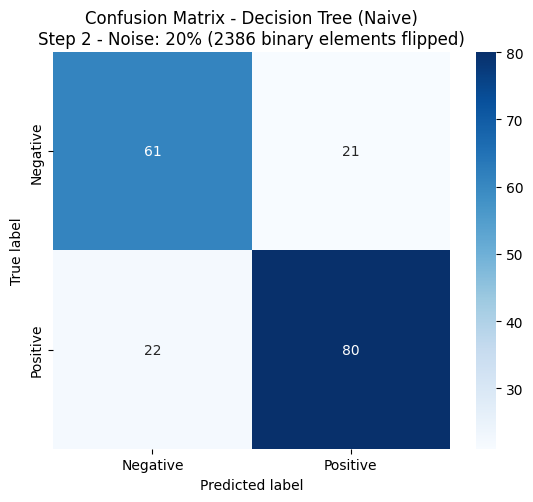

Feature Importances: [0.08734849 0.01306023 0.09108532 0.11522967 0.00329179 0.2152853
 0.0154169  0.2324003  0.02035635 0.02135442 0.01992598 0.00822639
 0.01387145 0.01010503 0.00453195 0.00833149 0.07398451 0.04619442]
✅ Step 2 completed (Noise: 20%)


===== Training Decision Tree (Naive) at Step 3 (Noise: 30%) =====
Generated dataset with 30% noise (3580 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0133
Training Decision Tree with Naive approach...
Training completed in 0.0034 seconds

RESULTS FOR STEP 3
  Binary elements flipped: 3580
  Accuracy Test:   0.7554
  Accuracy Train:  1.0000
  Precision:       0.7664
  Recall:          0.8039
  F1-score:        0.7847
  Training time:   0.0034 sec


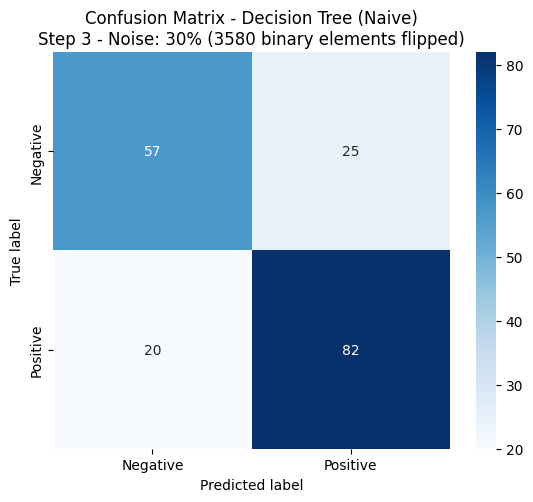

Feature Importances: [0.09414056 0.         0.07168013 0.15300677 0.03937952 0.20530696
 0.00871395 0.25368881 0.01139112 0.02936036 0.02298851 0.01120671
 0.01091704 0.01377959 0.01067918 0.         0.01999243 0.04376836]
✅ Step 3 completed (Noise: 30%)


===== Training Decision Tree (Naive) at Step 4 (Noise: 40%) =====
Generated dataset with 40% noise (4773 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0085
Training Decision Tree with Naive approach...
Training completed in 0.0031 seconds

RESULTS FOR STEP 4
  Binary elements flipped: 4773
  Accuracy Test:   0.7446
  Accuracy Train:  1.0000
  Precision:       0.7570
  Recall:          0.7941
  F1-score:        0.7751
  Training time:   0.0031 sec


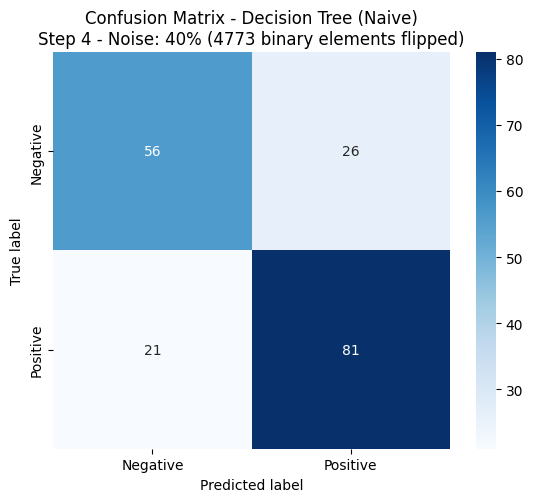

Feature Importances: [0.07831673 0.02134513 0.07069383 0.16493304 0.05261753 0.21460651
 0.00293965 0.24159562 0.01963594 0.02141155 0.02973211 0.01166672
 0.00826775 0.02473534 0.00863521 0.01194231 0.00937012 0.00755493]
✅ Step 4 completed (Noise: 40%)


===== Training Decision Tree (Naive) at Step 5 (Noise: 50%) =====
Generated dataset with 50% noise (5967 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0067
Training Decision Tree with Naive approach...
Training completed in 0.0029 seconds

RESULTS FOR STEP 5
  Binary elements flipped: 5967
  Accuracy Test:   0.7283
  Accuracy Train:  1.0000
  Precision:       0.7281
  Recall:          0.8137
  F1-score:        0.7685
  Training time:   0.0029 sec


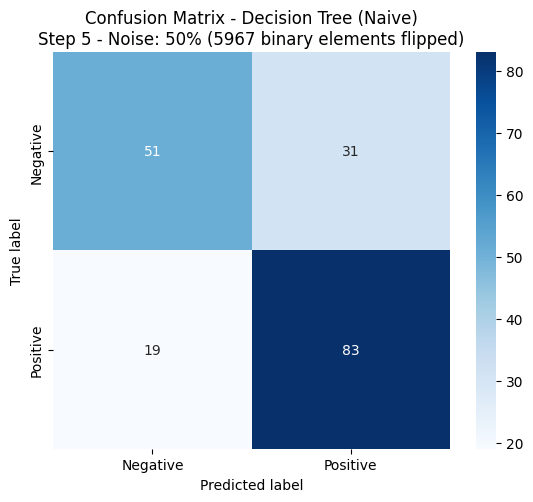

Feature Importances: [0.10526539 0.01064021 0.0647255  0.20923599 0.0116361  0.22467209
 0.01301843 0.22549539 0.02024828 0.00293965 0.         0.01792356
 0.02454778 0.01263129 0.01136044 0.01041167 0.01679797 0.01845028]
✅ Step 5 completed (Noise: 50%)


===== Training Decision Tree (Naive) at Step 6 (Noise: 60%) =====
Generated dataset with 60% noise (7160 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0087
Training Decision Tree with Naive approach...
Training completed in 0.0029 seconds

RESULTS FOR STEP 6
  Binary elements flipped: 7160
  Accuracy Test:   0.6685
  Accuracy Train:  1.0000
  Precision:       0.6952
  Recall:          0.7157
  F1-score:        0.7053
  Training time:   0.0029 sec


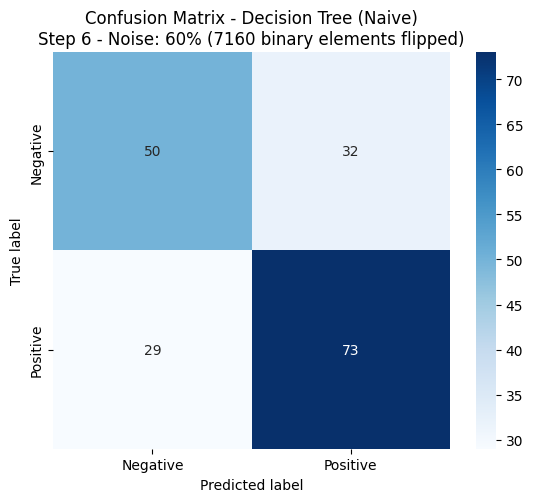

Feature Importances: [0.08455548 0.01884545 0.06098301 0.17567717 0.01991115 0.20105329
 0.0255841  0.23823734 0.013186   0.01541749 0.04623161 0.01829076
 0.00780843 0.02567713 0.00945293 0.         0.03265809 0.00643057]
✅ Step 6 completed (Noise: 60%)


===== Training Decision Tree (Naive) at Step 7 (Noise: 70%) =====
Generated dataset with 70% noise (8353 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0151
Training Decision Tree with Naive approach...
Training completed in 0.0037 seconds

RESULTS FOR STEP 7
  Binary elements flipped: 8353
  Accuracy Test:   0.5870
  Accuracy Train:  1.0000
  Precision:       0.6140
  Recall:          0.6863
  F1-score:        0.6481
  Training time:   0.0037 sec


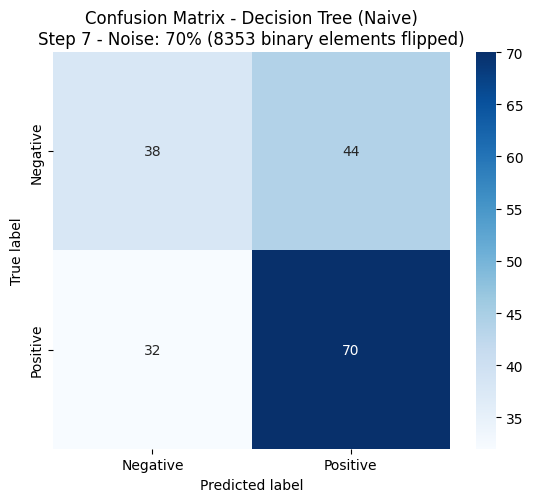

Feature Importances: [0.10977619 0.02974539 0.06271154 0.1562779  0.00210521 0.19481018
 0.00964571 0.21799917 0.02853172 0.01413869 0.01792809 0.01497382
 0.00413388 0.02711858 0.0099213  0.01348887 0.02089904 0.06579473]
✅ Step 7 completed (Noise: 70%)


===== Training Decision Tree (Naive) at Step 8 (Noise: 80%) =====
Generated dataset with 80% noise (9547 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0266
Training Decision Tree with Naive approach...
Training completed in 0.0025 seconds

RESULTS FOR STEP 8
  Binary elements flipped: 9547
  Accuracy Test:   0.4457
  Accuracy Train:  1.0000
  Precision:       0.5000
  Recall:          0.5000
  F1-score:        0.5000
  Training time:   0.0025 sec


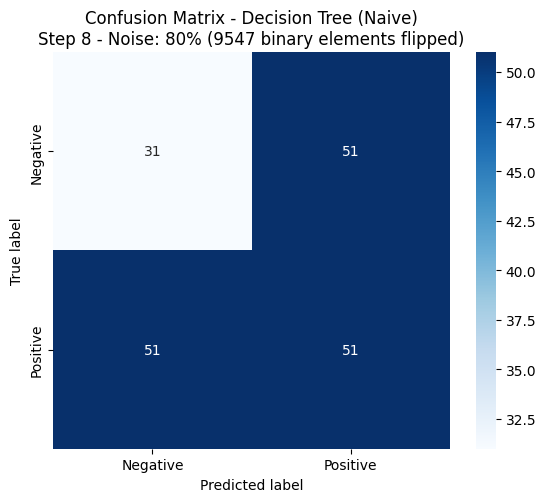

Feature Importances: [0.09864717 0.01530787 0.10826794 0.10833485 0.03301934 0.15915926
 0.01603379 0.22322871 0.01736839 0.00893705 0.01897714 0.00275592
 0.01400925 0.00897204 0.02664053 0.00115486 0.03694392 0.10224196]
✅ Step 8 completed (Noise: 80%)


===== Training Decision Tree (Naive) at Step 9 (Noise: 90%) =====
Generated dataset with 90% noise (10740 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0426
Training Decision Tree with Naive approach...
Training completed in 0.0025 seconds

RESULTS FOR STEP 9
  Binary elements flipped: 10740
  Accuracy Test:   0.4185
  Accuracy Train:  1.0000
  Precision:       0.4603
  Recall:          0.2843
  F1-score:        0.3515
  Training time:   0.0025 sec


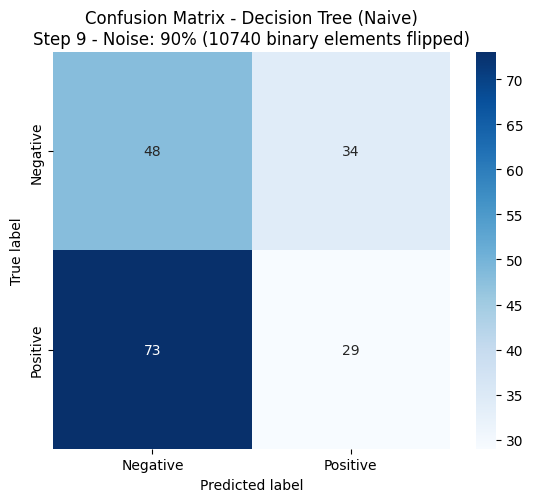

Feature Importances: [0.06914249 0.02912288 0.04686987 0.08432232 0.00766407 0.16349862
 0.01173627 0.12395457 0.0560548  0.02320251 0.01984186 0.0141103
 0.01253286 0.00801642 0.         0.00413388 0.02355105 0.30224524]
✅ Step 9 completed (Noise: 90%)


===== Training Decision Tree (Naive) at Step 10 (Noise: 100%) =====
Generated dataset with 100% noise (11934 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0644
Training Decision Tree with Naive approach...
Training completed in 0.0022 seconds

RESULTS FOR STEP 10
  Binary elements flipped: 11934
  Accuracy Test:   0.4402
  Accuracy Train:  1.0000
  Precision:       0.4930
  Recall:          0.3431
  F1-score:        0.4046
  Training time:   0.0022 sec


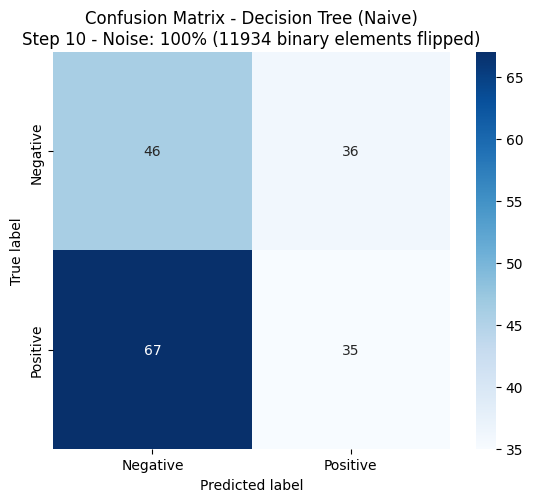

Feature Importances: [0.07565232 0.02854369 0.05709679 0.07417179 0.00425199 0.09569938
 0.00144358 0.09902224 0.08774174 0.         0.00780843 0.00413388
 0.01732292 0.01573736 0.         0.01015489 0.         0.421219  ]
✅ Step 10 completed (Noise: 100%)

Training Decision Tree - Optimized approach...
Binary columns to modify: ['Sex', 'FastingBS', 'ExerciseAngina', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']
Original DataFrame with 918 rows.
Total binary elements to consider: 11934
Generating progressively noisy datasets and training Decision Tree (Optimized)...


===== Training Decision Tree (Optimized) at Step 0 (Noise: 0%) =====
Generated dataset with 0% noise (no modifications).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0644
Training De

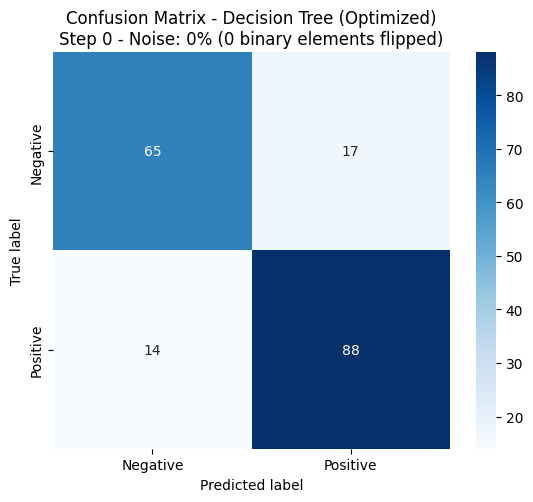

Feature Importances: [0.         0.04501474 0.         0.         0.00836537 0.
 0.         0.03175758 0.1577167  0.         0.         0.
 0.         0.         0.         0.         0.         0.75714561]
✅ Step 0 completed (Noise: 0%)


===== Training Decision Tree (Optimized) at Step 1 (Noise: 10%) =====
Generated dataset with 10% noise (1193 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0381
Training Decision Tree with Optimized approach...
Training completed in 0.0018 seconds

RESULTS FOR STEP 1
  Binary elements flipped: 1193
  Accuracy Test:   0.8152
  Accuracy Train:  0.7888
  Precision:       0.8148
  Recall:          0.8627
  F1-score:        0.8381
  Training time:   0.0018 sec


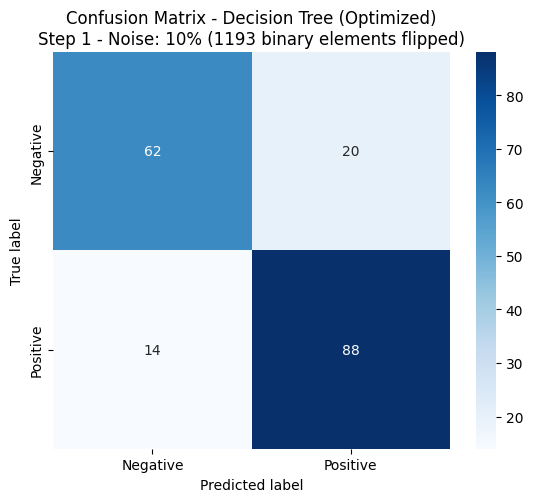

Feature Importances: [0.         0.         0.         0.         0.0349923  0.
 0.06272405 0.         0.23011859 0.         0.         0.
 0.         0.         0.         0.         0.02652468 0.64564037]
✅ Step 1 completed (Noise: 10%)


===== Training Decision Tree (Optimized) at Step 2 (Noise: 20%) =====
Generated dataset with 20% noise (2386 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0264
Training Decision Tree with Optimized approach...
Training completed in 0.0011 seconds

RESULTS FOR STEP 2
  Binary elements flipped: 2386
  Accuracy Test:   0.8098
  Accuracy Train:  0.7452
  Precision:       0.7913
  Recall:          0.8922
  F1-score:        0.8387
  Training time:   0.0011 sec


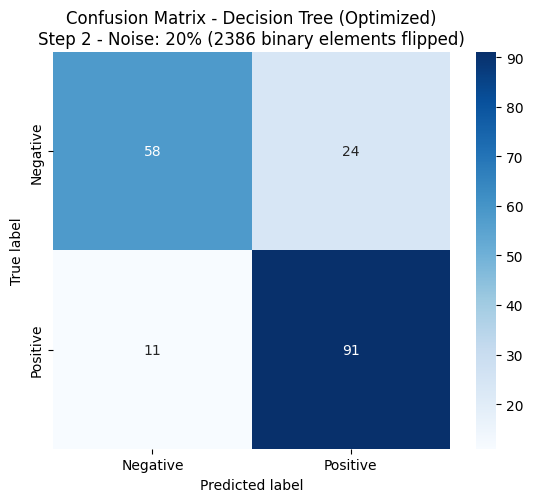

Feature Importances: [0.         0.03626752 0.         0.         0.         0.
 0.06664205 0.08686472 0.14139487 0.         0.         0.
 0.         0.         0.         0.         0.18234659 0.48648425]
✅ Step 2 completed (Noise: 20%)


===== Training Decision Tree (Optimized) at Step 3 (Noise: 30%) =====
Generated dataset with 30% noise (3580 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0133
Training Decision Tree with Optimized approach...
Training completed in 0.0010 seconds

RESULTS FOR STEP 3
  Binary elements flipped: 3580
  Accuracy Test:   0.7935
  Accuracy Train:  0.7098
  Precision:       0.8404
  Recall:          0.7745
  F1-score:        0.8061
  Training time:   0.0010 sec


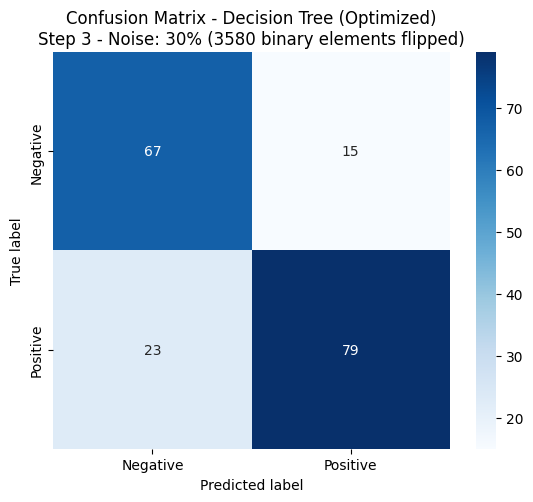

Feature Importances: [0.1522944  0.         0.         0.         0.         0.13592389
 0.         0.23534002 0.         0.07940859 0.         0.
 0.         0.         0.         0.         0.         0.3970331 ]
✅ Step 3 completed (Noise: 30%)


===== Training Decision Tree (Optimized) at Step 4 (Noise: 40%) =====
Generated dataset with 40% noise (4773 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0085
Training Decision Tree with Optimized approach...
Training completed in 0.0016 seconds

RESULTS FOR STEP 4
  Binary elements flipped: 4773
  Accuracy Test:   0.7500
  Accuracy Train:  0.6826
  Precision:       0.8182
  Recall:          0.7059
  F1-score:        0.7579
  Training time:   0.0016 sec


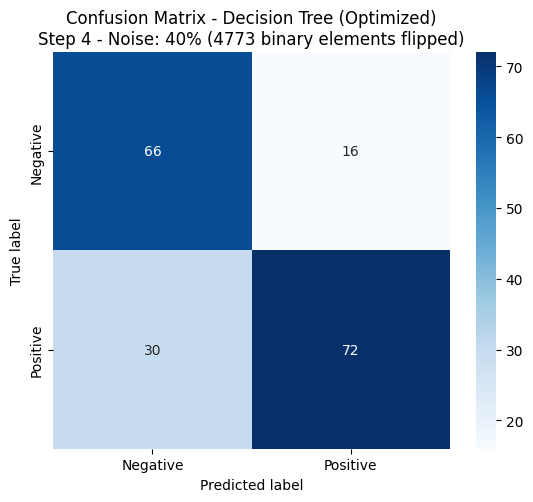

Feature Importances: [0.11342897 0.         0.         0.         0.         0.10658874
 0.         0.65335381 0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.12662848]
✅ Step 4 completed (Noise: 40%)


===== Training Decision Tree (Optimized) at Step 5 (Noise: 50%) =====
Generated dataset with 50% noise (5967 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0067
Training Decision Tree with Optimized approach...
Training completed in 0.0010 seconds

RESULTS FOR STEP 5
  Binary elements flipped: 5967
  Accuracy Test:   0.7554
  Accuracy Train:  0.7057
  Precision:       0.8276
  Recall:          0.7059
  F1-score:        0.7619
  Training time:   0.0010 sec


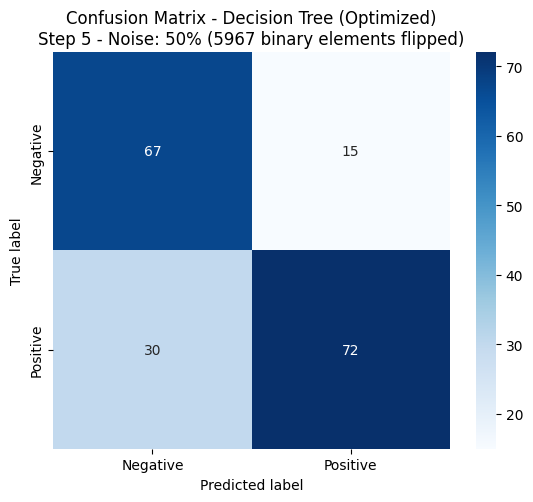

Feature Importances: [0.01483    0.         0.01285267 0.         0.         0.
 0.         0.97231733 0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.        ]
✅ Step 5 completed (Noise: 50%)


===== Training Decision Tree (Optimized) at Step 6 (Noise: 60%) =====
Generated dataset with 60% noise (7160 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0087
Training Decision Tree with Optimized approach...
Training completed in 0.0011 seconds

RESULTS FOR STEP 6
  Binary elements flipped: 7160
  Accuracy Test:   0.7120
  Accuracy Train:  0.7262
  Precision:       0.7248
  Recall:          0.7745
  F1-score:        0.7488
  Training time:   0.0011 sec


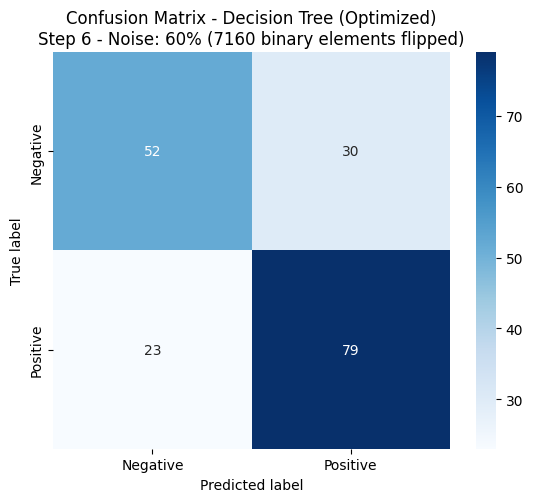

Feature Importances: [0.12647629 0.         0.         0.         0.         0.08469439
 0.         0.69146908 0.         0.         0.         0.
 0.         0.         0.         0.         0.         0.09736024]
✅ Step 6 completed (Noise: 60%)


===== Training Decision Tree (Optimized) at Step 7 (Noise: 70%) =====
Generated dataset with 70% noise (8353 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0151
Training Decision Tree with Optimized approach...
Training completed in 0.0011 seconds

RESULTS FOR STEP 7
  Binary elements flipped: 8353
  Accuracy Test:   0.2446
  Accuracy Train:  0.7302
  Precision:       0.2824
  Recall:          0.2353
  F1-score:        0.2567
  Training time:   0.0011 sec


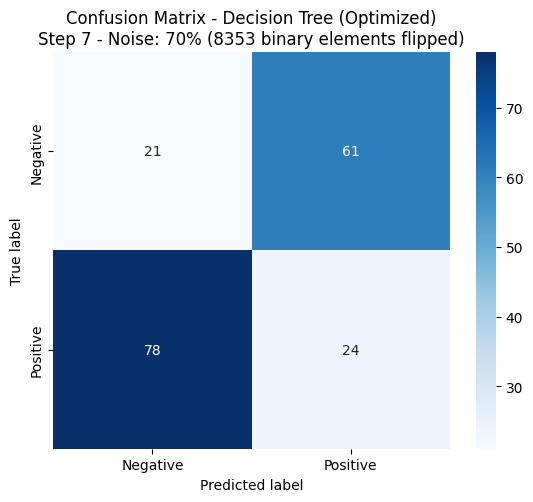

Feature Importances: [0.         0.07490236 0.         0.10435648 0.         0.06680455
 0.         0.25853234 0.         0.         0.06995656 0.
 0.         0.         0.         0.         0.06611815 0.35932957]
✅ Step 7 completed (Noise: 70%)


===== Training Decision Tree (Optimized) at Step 8 (Noise: 80%) =====
Generated dataset with 80% noise (9547 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0266
Training Decision Tree with Optimized approach...
Training completed in 0.0011 seconds

RESULTS FOR STEP 8
  Binary elements flipped: 9547
  Accuracy Test:   0.1957
  Accuracy Train:  0.7684
  Precision:       0.1892
  Recall:          0.1373
  F1-score:        0.1591
  Training time:   0.0011 sec


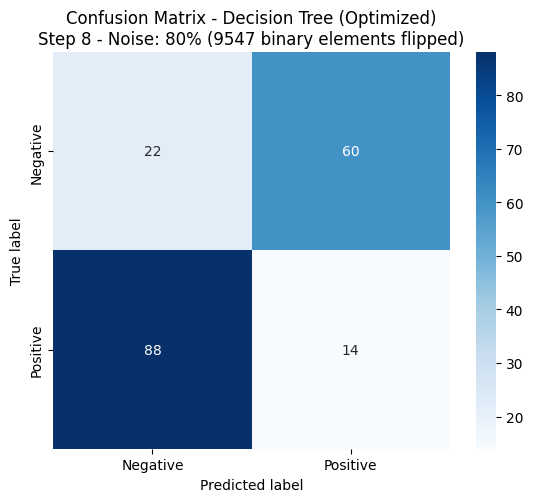

Feature Importances: [0.         0.0577502  0.         0.         0.01449549 0.
 0.07521038 0.288674   0.07668378 0.         0.         0.
 0.         0.         0.         0.         0.06147057 0.42571558]
✅ Step 8 completed (Noise: 80%)


===== Training Decision Tree (Optimized) at Step 9 (Noise: 90%) =====
Generated dataset with 90% noise (10740 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0426
Training Decision Tree with Optimized approach...
Training completed in 0.0010 seconds

RESULTS FOR STEP 9
  Binary elements flipped: 10740
  Accuracy Test:   0.2446
  Accuracy Train:  0.8093
  Precision:       0.2874
  Recall:          0.2451
  F1-score:        0.2646
  Training time:   0.0010 sec


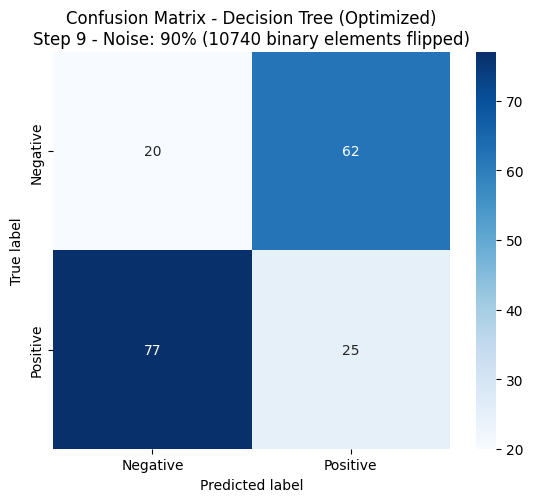

Feature Importances: [0.         0.04257736 0.         0.         0.         0.02751237
 0.         0.14258434 0.12913054 0.         0.         0.
 0.         0.         0.         0.         0.         0.6581954 ]
✅ Step 9 completed (Noise: 90%)


===== Training Decision Tree (Optimized) at Step 10 (Noise: 100%) =====
Generated dataset with 100% noise (11934 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0644
Training Decision Tree with Optimized approach...
Training completed in 0.0011 seconds

RESULTS FOR STEP 10
  Binary elements flipped: 11934
  Accuracy Test:   0.1739
  Accuracy Train:  0.8529
  Precision:       0.2024
  Recall:          0.1667
  F1-score:        0.1828
  Training time:   0.0011 sec


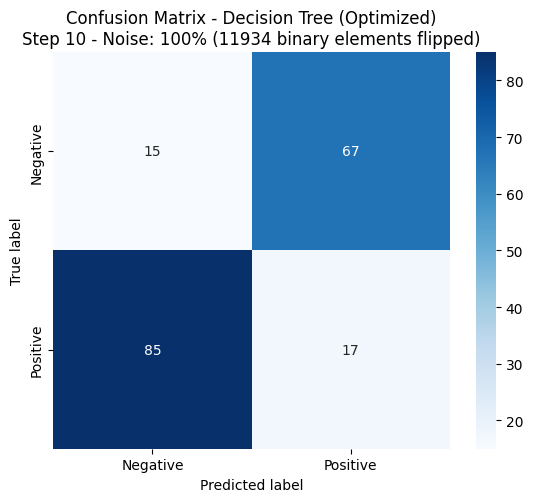

Feature Importances: [0.         0.04520491 0.         0.         0.00840071 0.
 0.0276671  0.         0.158383   0.         0.         0.
 0.         0.         0.         0.         0.         0.76034428]
✅ Step 10 completed (Noise: 100%)



--- INIZIO TRAINING: SVM ---
Training SVM - Naive approach...
Binary columns to modify: ['Sex', 'FastingBS', 'ExerciseAngina', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']
Original DataFrame with 918 rows.
Total binary elements to consider: 11934
Generating progressively noisy datasets and training SVM (Naive)...


===== Training SVM (Naive) at Step 0 (Noise: 0%) =====
Generated dataset with 0% noise (no modifications).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0644
Training SVM with Naive approach...
Tr

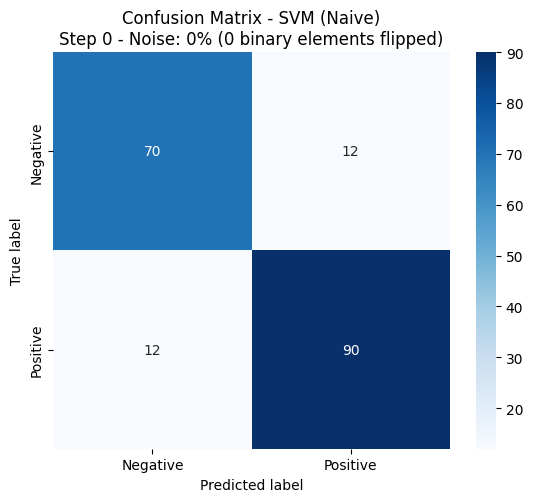

✅ Step 0 completed (Noise: 0%)


===== Training SVM (Naive) at Step 1 (Noise: 10%) =====
Generated dataset with 10% noise (1193 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0381
Training SVM with Naive approach...
Training completed in 0.0066 seconds

RESULTS FOR STEP 1
  Binary elements flipped: 1193
  Accuracy Test:   0.8859
  Accuracy Train:  0.8924
  Precision:       0.8932
  Recall:          0.9020
  F1-score:        0.8976
  Training time:   0.0066 sec


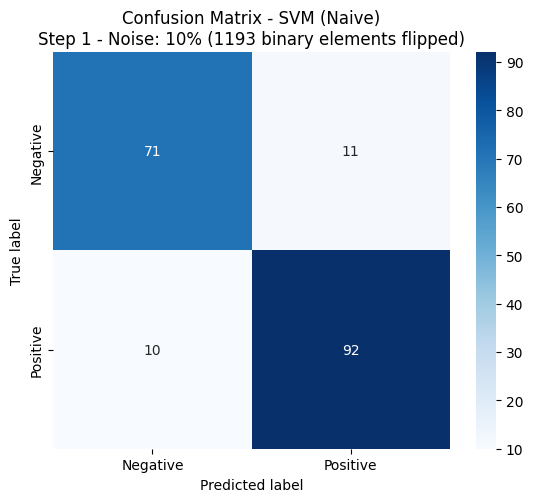

✅ Step 1 completed (Noise: 10%)


===== Training SVM (Naive) at Step 2 (Noise: 20%) =====
Generated dataset with 20% noise (2386 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0264
Training SVM with Naive approach...
Training completed in 0.0074 seconds

RESULTS FOR STEP 2
  Binary elements flipped: 2386
  Accuracy Test:   0.8750
  Accuracy Train:  0.8678
  Precision:       0.8911
  Recall:          0.8824
  F1-score:        0.8867
  Training time:   0.0074 sec


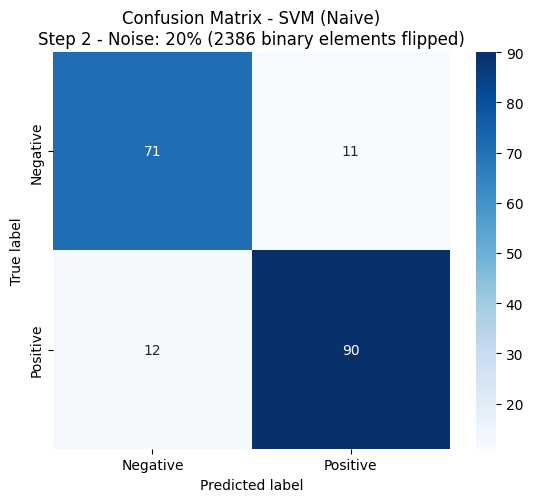

✅ Step 2 completed (Noise: 20%)


===== Training SVM (Naive) at Step 3 (Noise: 30%) =====
Generated dataset with 30% noise (3580 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0133
Training SVM with Naive approach...
Training completed in 0.0097 seconds

RESULTS FOR STEP 3
  Binary elements flipped: 3580
  Accuracy Test:   0.8424
  Accuracy Train:  0.8420
  Precision:       0.8614
  Recall:          0.8529
  F1-score:        0.8571
  Training time:   0.0097 sec


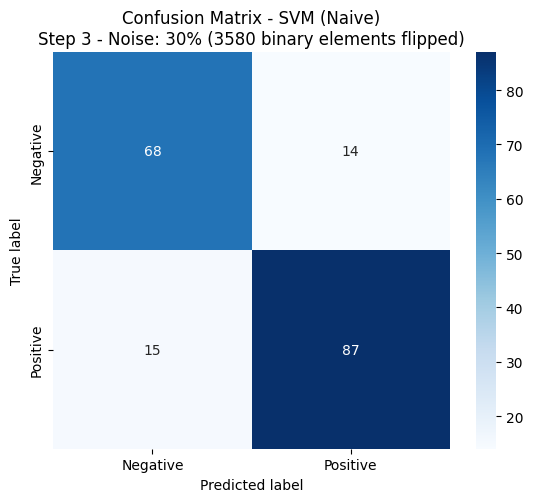

✅ Step 3 completed (Noise: 30%)


===== Training SVM (Naive) at Step 4 (Noise: 40%) =====
Generated dataset with 40% noise (4773 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0085
Training SVM with Naive approach...
Training completed in 0.0074 seconds

RESULTS FOR STEP 4
  Binary elements flipped: 4773
  Accuracy Test:   0.8152
  Accuracy Train:  0.8433
  Precision:       0.8469
  Recall:          0.8137
  F1-score:        0.8300
  Training time:   0.0074 sec


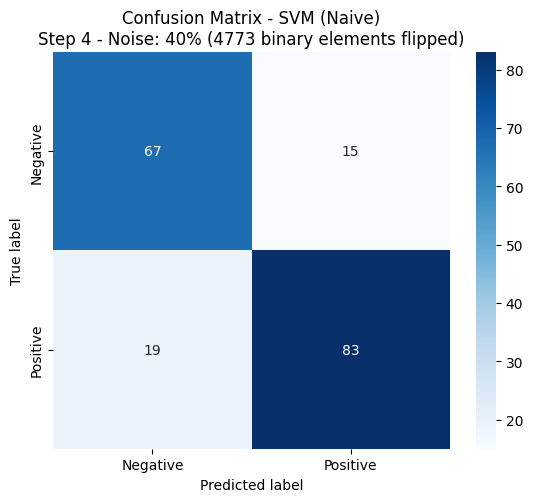

✅ Step 4 completed (Noise: 40%)


===== Training SVM (Naive) at Step 5 (Noise: 50%) =====
Generated dataset with 50% noise (5967 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0067
Training SVM with Naive approach...
Training completed in 0.0094 seconds

RESULTS FOR STEP 5
  Binary elements flipped: 5967
  Accuracy Test:   0.7609
  Accuracy Train:  0.8283
  Precision:       0.7959
  Recall:          0.7647
  F1-score:        0.7800
  Training time:   0.0094 sec


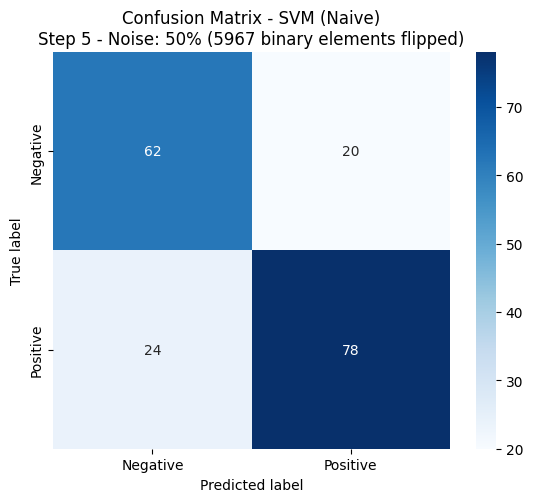

✅ Step 5 completed (Noise: 50%)


===== Training SVM (Naive) at Step 6 (Noise: 60%) =====
Generated dataset with 60% noise (7160 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0087
Training SVM with Naive approach...
Training completed in 0.0079 seconds

RESULTS FOR STEP 6
  Binary elements flipped: 7160
  Accuracy Test:   0.6413
  Accuracy Train:  0.8365
  Precision:       0.6837
  Recall:          0.6569
  F1-score:        0.6700
  Training time:   0.0079 sec


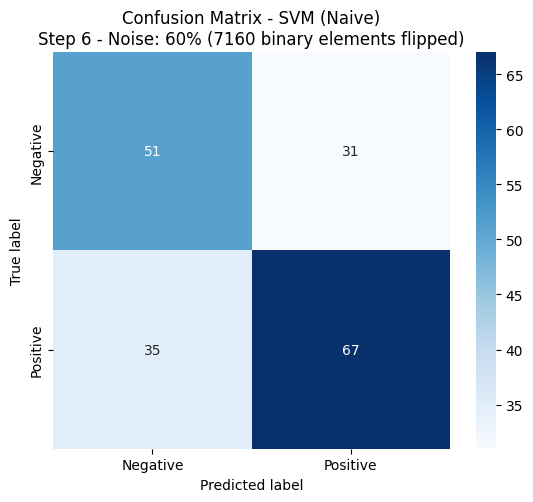

✅ Step 6 completed (Noise: 60%)


===== Training SVM (Naive) at Step 7 (Noise: 70%) =====
Generated dataset with 70% noise (8353 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0151
Training SVM with Naive approach...
Training completed in 0.0108 seconds

RESULTS FOR STEP 7
  Binary elements flipped: 8353
  Accuracy Test:   0.5163
  Accuracy Train:  0.8692
  Precision:       0.5575
  Recall:          0.6176
  F1-score:        0.5860
  Training time:   0.0108 sec


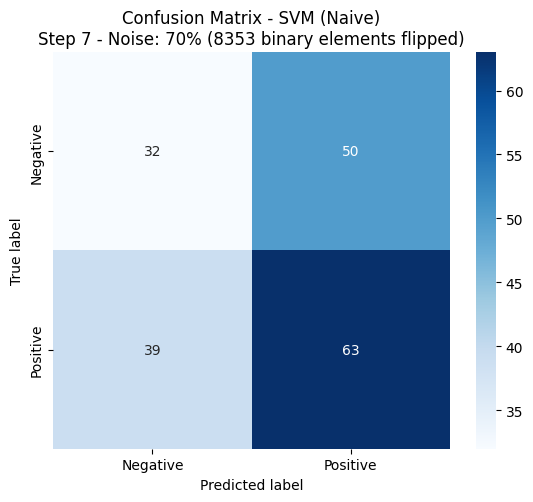

✅ Step 7 completed (Noise: 70%)


===== Training SVM (Naive) at Step 8 (Noise: 80%) =====
Generated dataset with 80% noise (9547 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0266
Training SVM with Naive approach...
Training completed in 0.0075 seconds

RESULTS FOR STEP 8
  Binary elements flipped: 9547
  Accuracy Test:   0.4891
  Accuracy Train:  0.8638
  Precision:       0.5392
  Recall:          0.5392
  F1-score:        0.5392
  Training time:   0.0075 sec


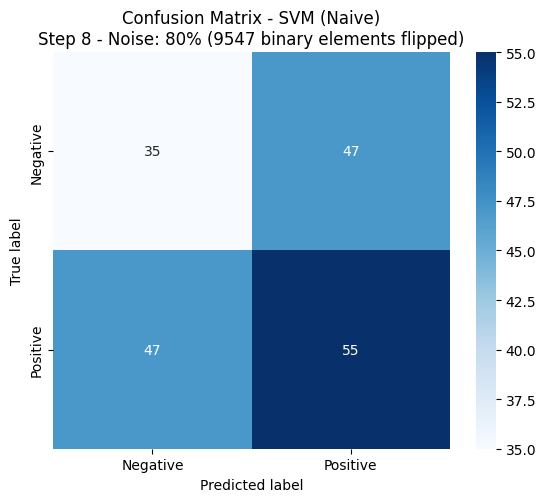

✅ Step 8 completed (Noise: 80%)


===== Training SVM (Naive) at Step 9 (Noise: 90%) =====
Generated dataset with 90% noise (10740 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0426
Training SVM with Naive approach...
Training completed in 0.0058 seconds

RESULTS FOR STEP 9
  Binary elements flipped: 10740
  Accuracy Test:   0.4076
  Accuracy Train:  0.8910
  Precision:       0.4598
  Recall:          0.3922
  F1-score:        0.4233
  Training time:   0.0058 sec


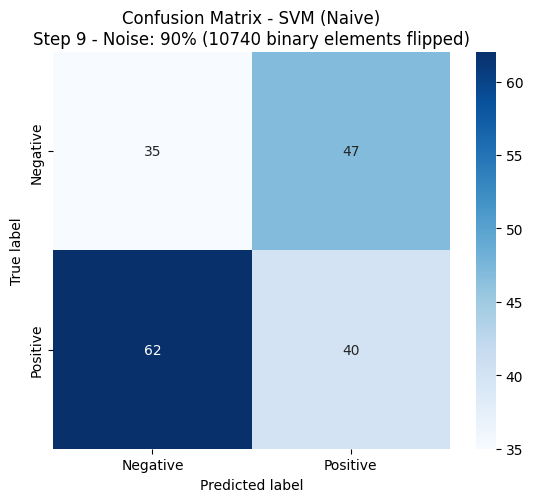

✅ Step 9 completed (Noise: 90%)


===== Training SVM (Naive) at Step 10 (Noise: 100%) =====
Generated dataset with 100% noise (11934 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0644
Training SVM with Naive approach...
Training completed in 0.0057 seconds

RESULTS FOR STEP 10
  Binary elements flipped: 11934
  Accuracy Test:   0.3261
  Accuracy Train:  0.8924
  Precision:       0.3962
  Recall:          0.4118
  F1-score:        0.4038
  Training time:   0.0057 sec


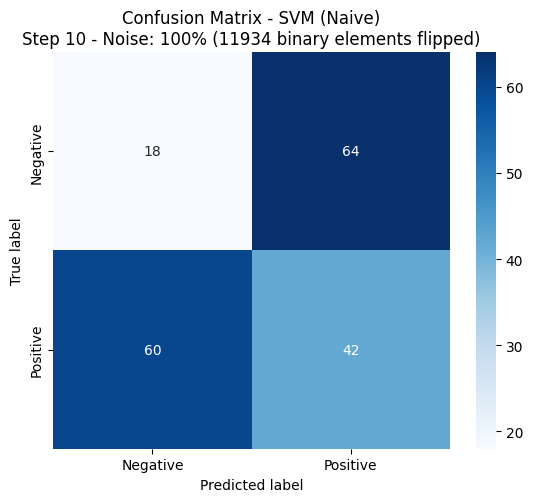

✅ Step 10 completed (Noise: 100%)

Training SVM - Optimized approach...
Binary columns to modify: ['Sex', 'FastingBS', 'ExerciseAngina', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']
Original DataFrame with 918 rows.
Total binary elements to consider: 11934
Generating progressively noisy datasets and training SVM (Optimized)...


===== Training SVM (Optimized) at Step 0 (Noise: 0%) =====
Generated dataset with 0% noise (no modifications).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0644
Training SVM with Optimized approach...
Training completed in 0.0062 seconds

RESULTS FOR STEP 0
  Binary elements flipped: 0
  Accuracy Test:   0.8750
  Accuracy Train:  0.8842
  Precision:       0.8835
  Recall:          0.8922
  F1-score:        0.8878
  Traini

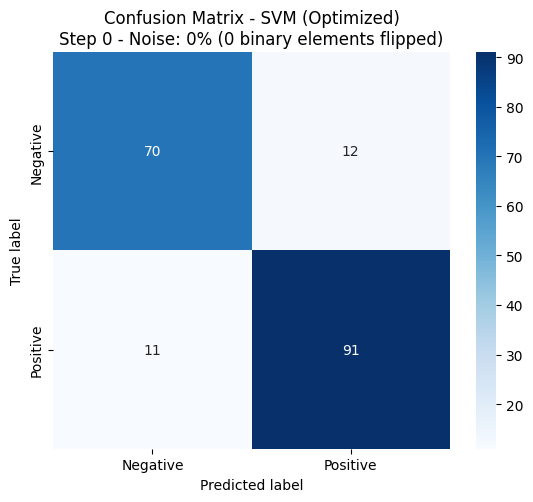

✅ Step 0 completed (Noise: 0%)


===== Training SVM (Optimized) at Step 1 (Noise: 10%) =====
Generated dataset with 10% noise (1193 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0381
Training SVM with Optimized approach...
Training completed in 0.0064 seconds

RESULTS FOR STEP 1
  Binary elements flipped: 1193
  Accuracy Test:   0.8804
  Accuracy Train:  0.8638
  Precision:       0.9000
  Recall:          0.8824
  F1-score:        0.8911
  Training time:   0.0064 sec


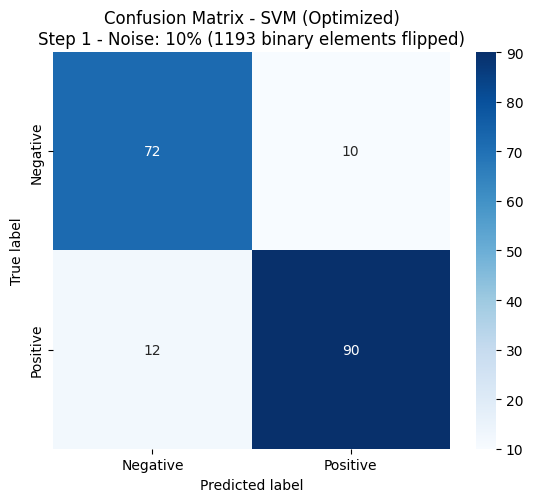

✅ Step 1 completed (Noise: 10%)


===== Training SVM (Optimized) at Step 2 (Noise: 20%) =====
Generated dataset with 20% noise (2386 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0264
Training SVM with Optimized approach...
Training completed in 0.0094 seconds

RESULTS FOR STEP 2
  Binary elements flipped: 2386
  Accuracy Test:   0.8804
  Accuracy Train:  0.8311
  Precision:       0.8846
  Recall:          0.9020
  F1-score:        0.8932
  Training time:   0.0094 sec


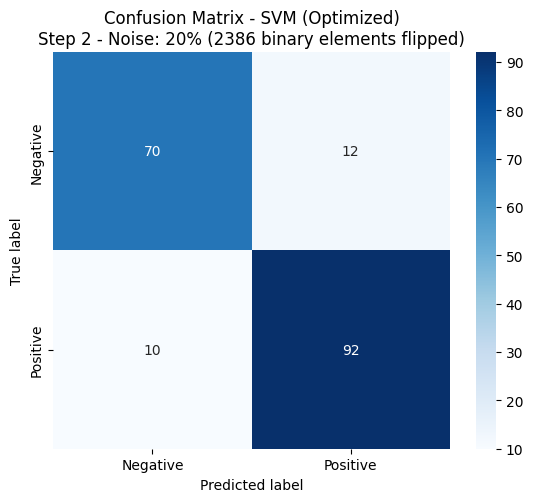

✅ Step 2 completed (Noise: 20%)


===== Training SVM (Optimized) at Step 3 (Noise: 30%) =====
Generated dataset with 30% noise (3580 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0133
Training SVM with Optimized approach...
Training completed in 0.0089 seconds

RESULTS FOR STEP 3
  Binary elements flipped: 3580
  Accuracy Test:   0.8533
  Accuracy Train:  0.8120
  Precision:       0.8571
  Recall:          0.8824
  F1-score:        0.8696
  Training time:   0.0089 sec


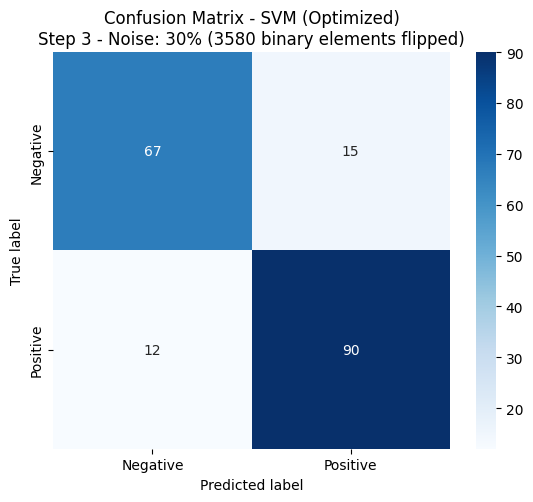

✅ Step 3 completed (Noise: 30%)


===== Training SVM (Optimized) at Step 4 (Noise: 40%) =====
Generated dataset with 40% noise (4773 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0085
Training SVM with Optimized approach...
Training completed in 0.0093 seconds

RESULTS FOR STEP 4
  Binary elements flipped: 4773
  Accuracy Test:   0.8098
  Accuracy Train:  0.7861
  Precision:       0.8454
  Recall:          0.8039
  F1-score:        0.8241
  Training time:   0.0093 sec


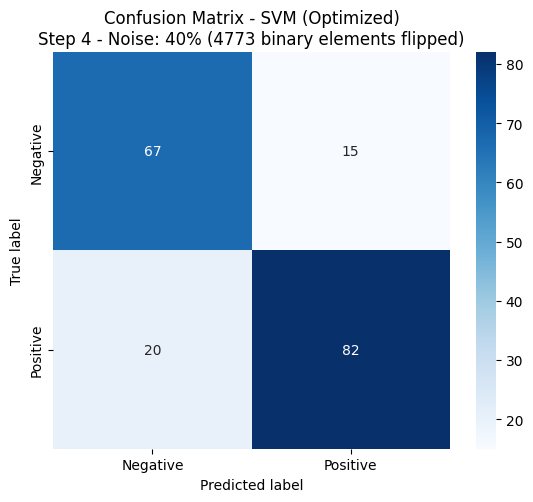

✅ Step 4 completed (Noise: 40%)


===== Training SVM (Optimized) at Step 5 (Noise: 50%) =====
Generated dataset with 50% noise (5967 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0067
Training SVM with Optimized approach...
Training completed in 0.0087 seconds

RESULTS FOR STEP 5
  Binary elements flipped: 5967
  Accuracy Test:   0.7283
  Accuracy Train:  0.7847
  Precision:       0.7653
  Recall:          0.7353
  F1-score:        0.7500
  Training time:   0.0087 sec


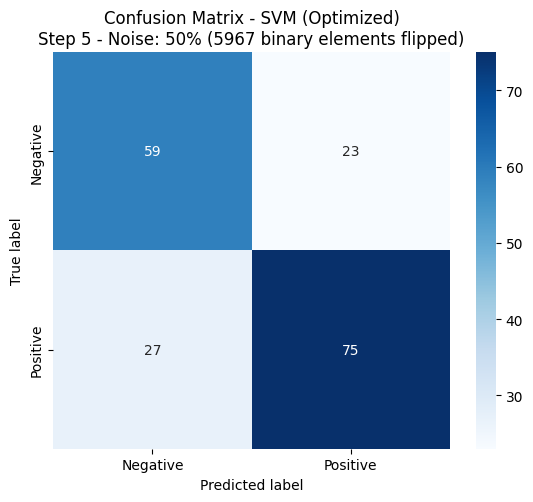

✅ Step 5 completed (Noise: 50%)


===== Training SVM (Optimized) at Step 6 (Noise: 60%) =====
Generated dataset with 60% noise (7160 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0087
Training SVM with Optimized approach...
Training completed in 0.0091 seconds

RESULTS FOR STEP 6
  Binary elements flipped: 7160
  Accuracy Test:   0.6359
  Accuracy Train:  0.8011
  Precision:       0.6882
  Recall:          0.6275
  F1-score:        0.6564
  Training time:   0.0091 sec


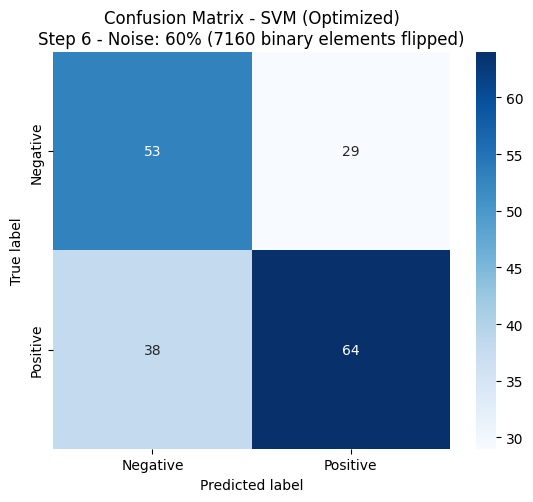

✅ Step 6 completed (Noise: 60%)


===== Training SVM (Optimized) at Step 7 (Noise: 70%) =====
Generated dataset with 70% noise (8353 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0151
Training SVM with Optimized approach...
Training completed in 0.0075 seconds

RESULTS FOR STEP 7
  Binary elements flipped: 8353
  Accuracy Test:   0.4620
  Accuracy Train:  0.8297
  Precision:       0.5124
  Recall:          0.6078
  F1-score:        0.5561
  Training time:   0.0075 sec


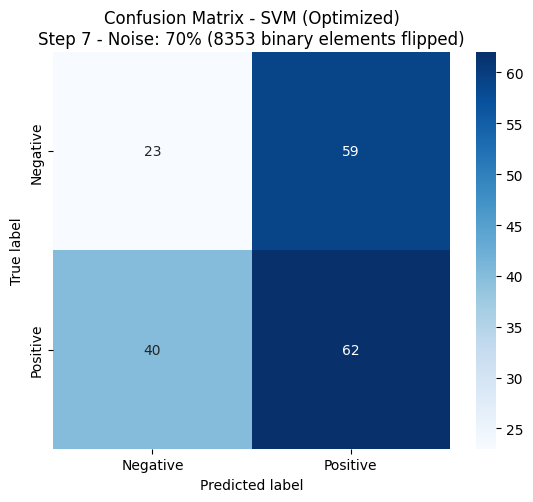

✅ Step 7 completed (Noise: 70%)


===== Training SVM (Optimized) at Step 8 (Noise: 80%) =====
Generated dataset with 80% noise (9547 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0266
Training SVM with Optimized approach...
Training completed in 0.0071 seconds

RESULTS FOR STEP 8
  Binary elements flipped: 9547
  Accuracy Test:   0.4293
  Accuracy Train:  0.8392
  Precision:       0.4845
  Recall:          0.4608
  F1-score:        0.4724
  Training time:   0.0071 sec


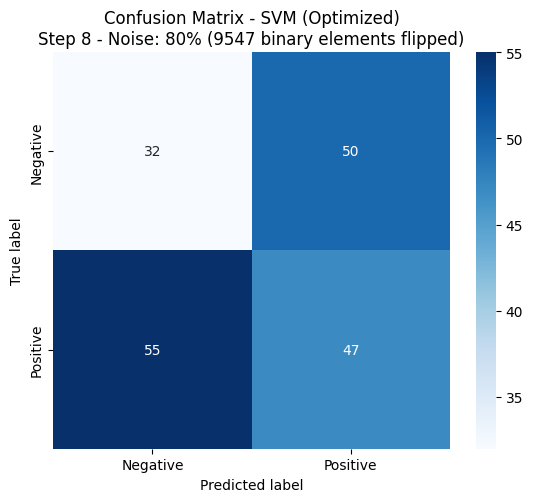

✅ Step 8 completed (Noise: 80%)


===== Training SVM (Optimized) at Step 9 (Noise: 90%) =====
Generated dataset with 90% noise (10740 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0426
Training SVM with Optimized approach...
Training completed in 0.0074 seconds

RESULTS FOR STEP 9
  Binary elements flipped: 10740
  Accuracy Test:   0.2717
  Accuracy Train:  0.8760
  Precision:       0.2333
  Recall:          0.1373
  F1-score:        0.1728
  Training time:   0.0074 sec


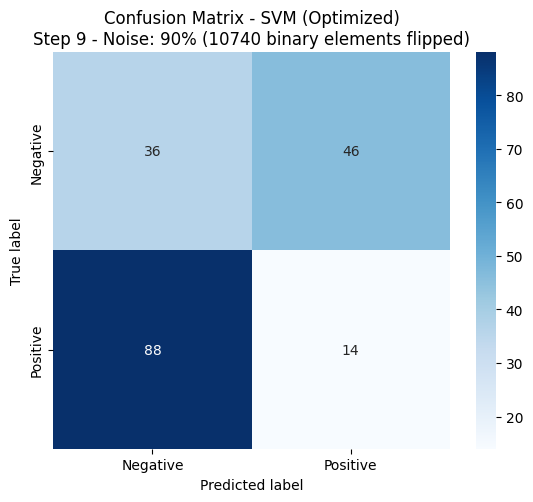

✅ Step 9 completed (Noise: 90%)


===== Training SVM (Optimized) at Step 10 (Noise: 100%) =====
Generated dataset with 100% noise (11934 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0644
Training SVM with Optimized approach...
Training completed in 0.0059 seconds

RESULTS FOR STEP 10
  Binary elements flipped: 11934
  Accuracy Test:   0.1902
  Accuracy Train:  0.8842
  Precision:       0.2299
  Recall:          0.1961
  F1-score:        0.2116
  Training time:   0.0059 sec


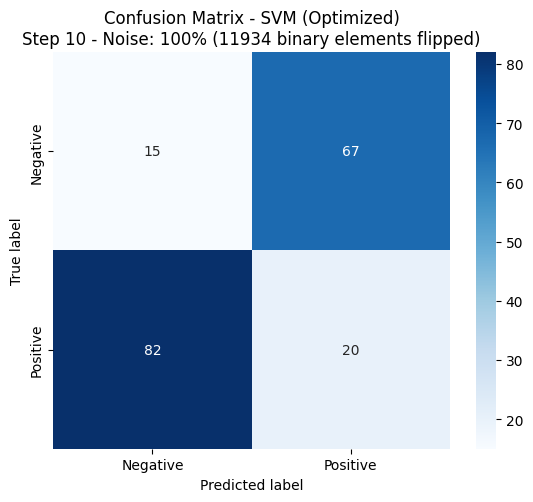

✅ Step 10 completed (Noise: 100%)



--- INIZIO TRAINING: NEURAL NETWORK (CUSTOM MODEL) ---
Training Neural Network - Naive approach...
Binary columns to modify: ['Sex', 'FastingBS', 'ExerciseAngina', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']
Original DataFrame with 918 rows.
Total binary elements to consider: 11934
Generating progressively noisy datasets and training Neural Network (Naive)...


===== Training Neural Network (Naive) at Step 0 (Noise: 0%) =====
Generated dataset with 0% noise (no modifications).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0644
Training Neural Network with Naive approach...
Training completed in 3.8396 seconds
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 655us/step

RESULTS FOR STEP 0
  B

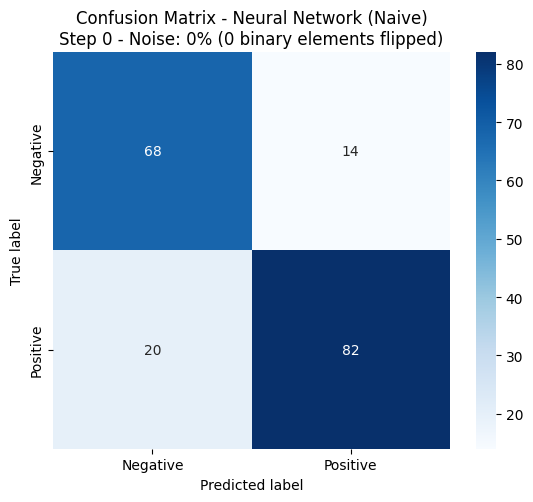

✅ Step 0 completed (Noise: 0%)


===== Training Neural Network (Naive) at Step 1 (Noise: 10%) =====
Generated dataset with 10% noise (1193 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0381
Training Neural Network with Naive approach...
Training completed in 3.1938 seconds
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 633us/step

RESULTS FOR STEP 1
  Binary elements flipped: 1193
  Accuracy Test:   0.8641
  Accuracy Train:  0.9850
  Precision:       0.8812
  Recall:          0.8725
  F1-score:        0.8768
  Training time:   3.1938 sec
  Val Accuracy:    0.8641
  Epochs completed: 50


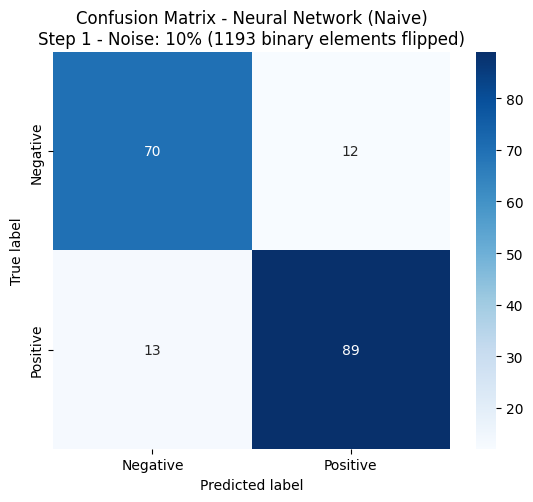

✅ Step 1 completed (Noise: 10%)


===== Training Neural Network (Naive) at Step 2 (Noise: 20%) =====
Generated dataset with 20% noise (2386 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0264
Training Neural Network with Naive approach...
Training completed in 3.3673 seconds
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 613us/step

RESULTS FOR STEP 2
  Binary elements flipped: 2386
  Accuracy Test:   0.8696
  Accuracy Train:  0.9864
  Precision:       0.8679
  Recall:          0.9020
  F1-score:        0.8846
  Training time:   3.3673 sec
  Val Accuracy:    0.8696
  Epochs completed: 50


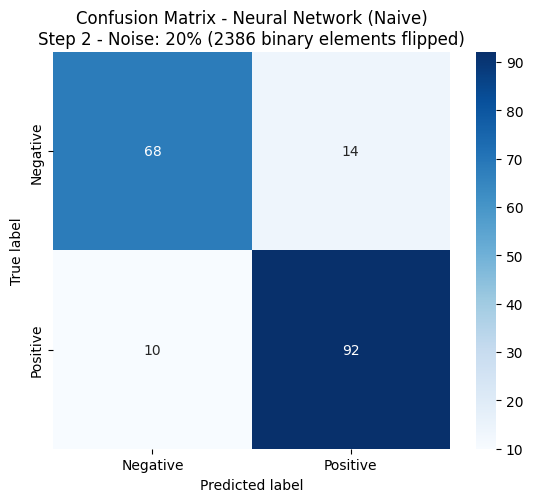

✅ Step 2 completed (Noise: 20%)


===== Training Neural Network (Naive) at Step 3 (Noise: 30%) =====
Generated dataset with 30% noise (3580 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0133
Training Neural Network with Naive approach...
Training completed in 3.2612 seconds
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 

RESULTS FOR STEP 3
  Binary elements flipped: 3580
  Accuracy Test:   0.8043
  Accuracy Train:  0.9864
  Precision:       0.8113
  Recall:          0.8431
  F1-score:        0.8269
  Training time:   3.2612 sec
  Val Accuracy:    0.8043
  Epochs completed: 50


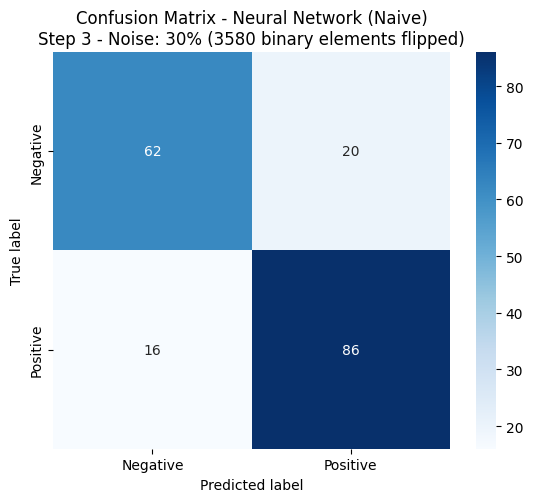

✅ Step 3 completed (Noise: 30%)


===== Training Neural Network (Naive) at Step 4 (Noise: 40%) =====
Generated dataset with 40% noise (4773 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0085
Training Neural Network with Naive approach...
Training completed in 3.8284 seconds
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 636us/step

RESULTS FOR STEP 4
  Binary elements flipped: 4773
  Accuracy Test:   0.7772
  Accuracy Train:  0.9864
  Precision:       0.8144
  Recall:          0.7745
  F1-score:        0.7940
  Training time:   3.8284 sec
  Val Accuracy:    0.7772
  Epochs completed: 50


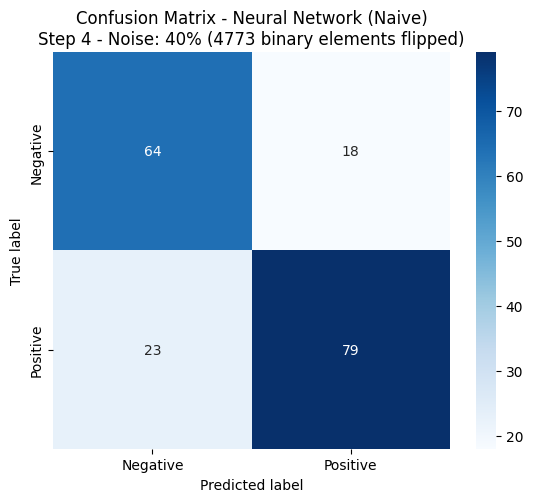

✅ Step 4 completed (Noise: 40%)


===== Training Neural Network (Naive) at Step 5 (Noise: 50%) =====
Generated dataset with 50% noise (5967 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0067
Training Neural Network with Naive approach...
Training completed in 3.3247 seconds
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 613us/step

RESULTS FOR STEP 5
  Binary elements flipped: 5967
  Accuracy Test:   0.7065
  Accuracy Train:  0.9837
  Precision:       0.7308
  Recall:          0.7451
  F1-score:        0.7379
  Training time:   3.3247 sec
  Val Accuracy:    0.7065
  Epochs completed: 50


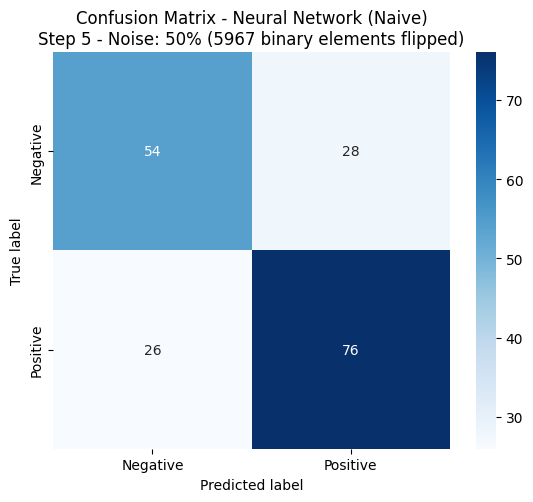

✅ Step 5 completed (Noise: 50%)


===== Training Neural Network (Naive) at Step 6 (Noise: 60%) =====
Generated dataset with 60% noise (7160 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0087
Training Neural Network with Naive approach...
Training completed in 3.3040 seconds
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 627us/step

RESULTS FOR STEP 6
  Binary elements flipped: 7160
  Accuracy Test:   0.6196
  Accuracy Train:  0.9796
  Precision:       0.6667
  Recall:          0.6275
  F1-score:        0.6465
  Training time:   3.3040 sec
  Val Accuracy:    0.6196
  Epochs completed: 50


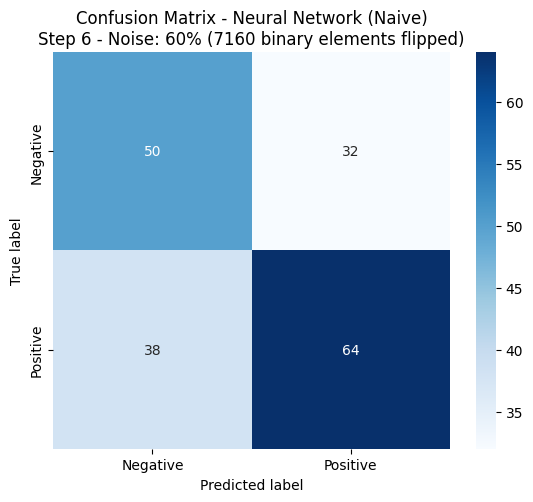

✅ Step 6 completed (Noise: 60%)


===== Training Neural Network (Naive) at Step 7 (Noise: 70%) =====
Generated dataset with 70% noise (8353 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0151
Training Neural Network with Naive approach...
Training completed in 3.2759 seconds
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 617us/step

RESULTS FOR STEP 7
  Binary elements flipped: 8353
  Accuracy Test:   0.4293
  Accuracy Train:  0.9850
  Precision:       0.4860
  Recall:          0.5098
  F1-score:        0.4976
  Training time:   3.2759 sec
  Val Accuracy:    0.4293
  Epochs completed: 50


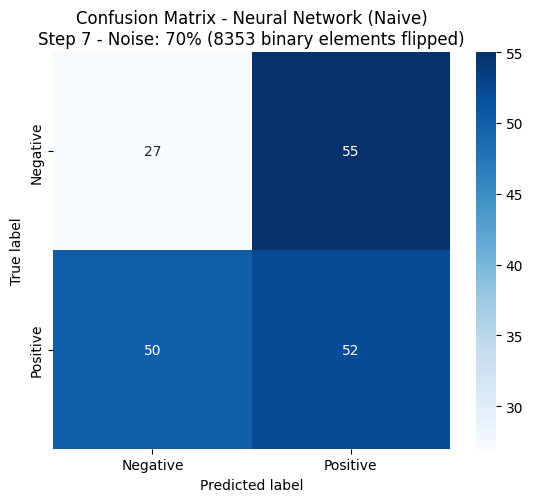

✅ Step 7 completed (Noise: 70%)


===== Training Neural Network (Naive) at Step 8 (Noise: 80%) =====
Generated dataset with 80% noise (9547 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0266
Training Neural Network with Naive approach...
Training completed in 3.2724 seconds
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 646us/step

RESULTS FOR STEP 8
  Binary elements flipped: 9547
  Accuracy Test:   0.5054
  Accuracy Train:  0.9837
  Precision:       0.5505
  Recall:          0.5882
  F1-score:        0.5687
  Training time:   3.2724 sec
  Val Accuracy:    0.5054
  Epochs completed: 50


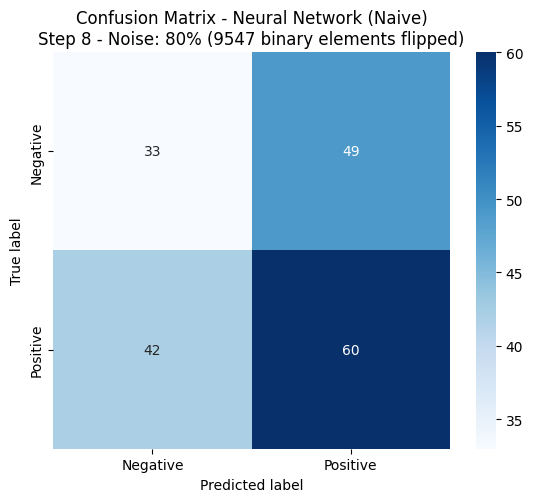

✅ Step 8 completed (Noise: 80%)


===== Training Neural Network (Naive) at Step 9 (Noise: 90%) =====
Generated dataset with 90% noise (10740 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0426
Training Neural Network with Naive approach...
Training completed in 3.3451 seconds
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 

RESULTS FOR STEP 9
  Binary elements flipped: 10740
  Accuracy Test:   0.2880
  Accuracy Train:  0.9796
  Precision:       0.3441
  Recall:          0.3137
  F1-score:        0.3282
  Training time:   3.3451 sec
  Val Accuracy:    0.2880
  Epochs completed: 50


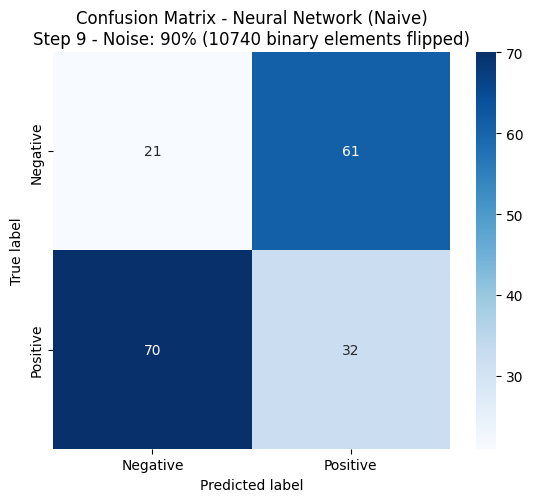

✅ Step 9 completed (Noise: 90%)


===== Training Neural Network (Naive) at Step 10 (Noise: 100%) =====
Generated dataset with 100% noise (11934 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0644
Training Neural Network with Naive approach...
Training completed in 3.2705 seconds
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 625us/step

RESULTS FOR STEP 10
  Binary elements flipped: 11934
  Accuracy Test:   0.3261
  Accuracy Train:  0.9700
  Precision:       0.3962
  Recall:          0.4118
  F1-score:        0.4038
  Training time:   3.2705 sec
  Val Accuracy:    0.3261
  Epochs completed: 50


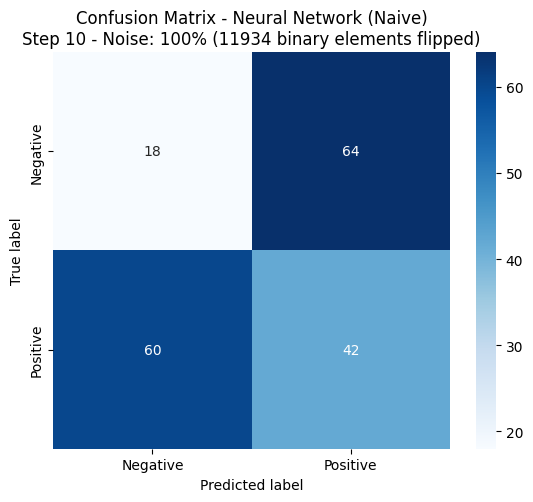

✅ Step 10 completed (Noise: 100%)

Training Neural Network - Optimized approach...
Binary columns to modify: ['Sex', 'FastingBS', 'ExerciseAngina', 'ChestPainType_ASY', 'ChestPainType_ATA', 'ChestPainType_NAP', 'ChestPainType_TA', 'RestingECG_LVH', 'RestingECG_Normal', 'RestingECG_ST', 'ST_Slope_Down', 'ST_Slope_Flat', 'ST_Slope_Up']
Original DataFrame with 918 rows.
Total binary elements to consider: 11934
Generating progressively noisy datasets and training Neural Network (Optimized)...


===== Training Neural Network (Optimized) at Step 0 (Noise: 0%) =====
Generated dataset with 0% noise (no modifications).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0644
Training Neural Network with Optimized approach...
Training completed in 5.5128 seconds
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 605us/step

RESULTS FOR STEP 0
  Binary elements flipped: 0
  Accuracy Test

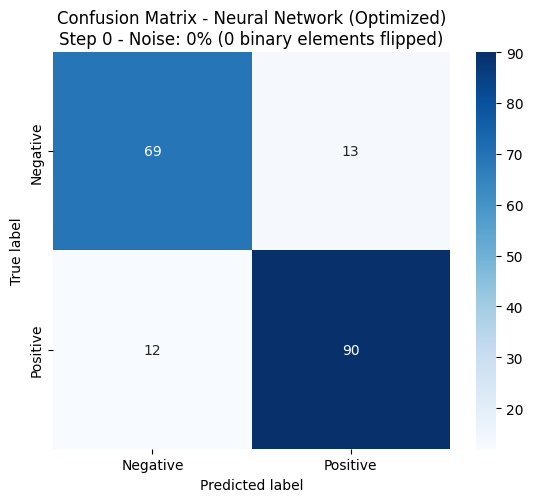

✅ Step 0 completed (Noise: 0%)


===== Training Neural Network (Optimized) at Step 1 (Noise: 10%) =====
Generated dataset with 10% noise (1193 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0381
Training Neural Network with Optimized approach...
Training completed in 6.4696 seconds
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 585us/step

RESULTS FOR STEP 1
  Binary elements flipped: 1193
  Accuracy Test:   0.8804
  Accuracy Train:  0.9169
  Precision:       0.8922
  Recall:          0.8922
  F1-score:        0.8922
  Training time:   6.4696 sec
  Val Accuracy:    0.8804
  Epochs completed: 100


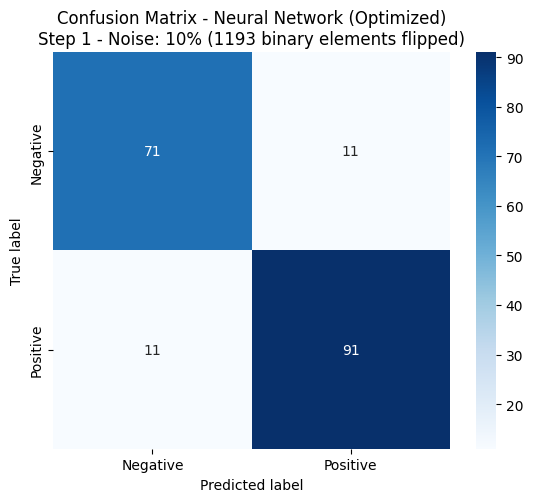

✅ Step 1 completed (Noise: 10%)


===== Training Neural Network (Optimized) at Step 2 (Noise: 20%) =====
Generated dataset with 20% noise (2386 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0264
Training Neural Network with Optimized approach...
Training completed in 6.3658 seconds
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 928us/step

RESULTS FOR STEP 2
  Binary elements flipped: 2386
  Accuracy Test:   0.8750
  Accuracy Train:  0.8856
  Precision:       0.8762
  Recall:          0.9020
  F1-score:        0.8889
  Training time:   6.3658 sec
  Val Accuracy:    0.8750
  Epochs completed: 100


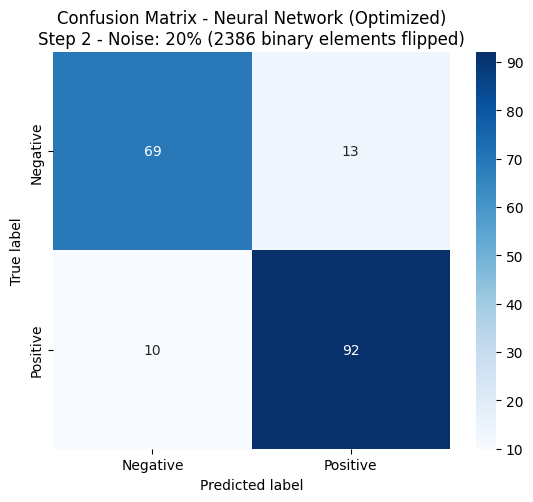

✅ Step 2 completed (Noise: 20%)


===== Training Neural Network (Optimized) at Step 3 (Noise: 30%) =====
Generated dataset with 30% noise (3580 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0133
Training Neural Network with Optimized approach...
Training completed in 6.0724 seconds
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 707us/step

RESULTS FOR STEP 3
  Binary elements flipped: 3580
  Accuracy Test:   0.8207
  Accuracy Train:  0.8815
  Precision:       0.8224
  Recall:          0.8627
  F1-score:        0.8421
  Training time:   6.0724 sec
  Val Accuracy:    0.8207
  Epochs completed: 100


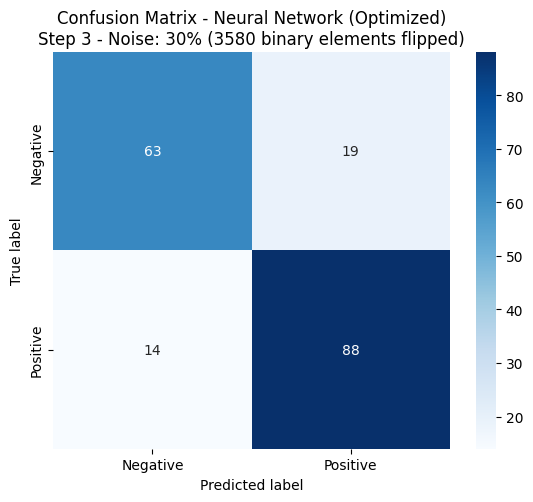

✅ Step 3 completed (Noise: 30%)


===== Training Neural Network (Optimized) at Step 4 (Noise: 40%) =====
Generated dataset with 40% noise (4773 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0085
Training Neural Network with Optimized approach...
Training completed in 5.8077 seconds
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 663us/step

RESULTS FOR STEP 4
  Binary elements flipped: 4773
  Accuracy Test:   0.7772
  Accuracy Train:  0.8842
  Precision:       0.8211
  Recall:          0.7647
  F1-score:        0.7919
  Training time:   5.8077 sec
  Val Accuracy:    0.7772
  Epochs completed: 100


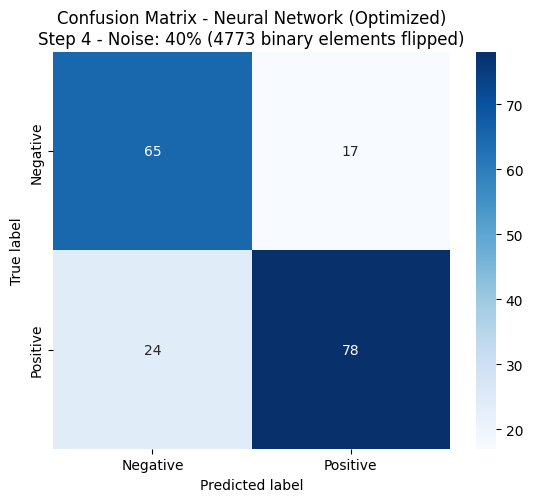

✅ Step 4 completed (Noise: 40%)


===== Training Neural Network (Optimized) at Step 5 (Noise: 50%) =====
Generated dataset with 50% noise (5967 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0067
Training Neural Network with Optimized approach...
Training completed in 5.7942 seconds
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 624us/step

RESULTS FOR STEP 5
  Binary elements flipped: 5967
  Accuracy Test:   0.7283
  Accuracy Train:  0.8706
  Precision:       0.7826
  Recall:          0.7059
  F1-score:        0.7423
  Training time:   5.7942 sec
  Val Accuracy:    0.7283
  Epochs completed: 100


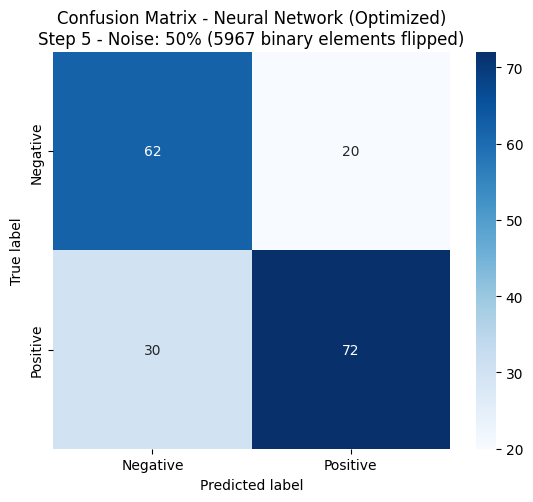

✅ Step 5 completed (Noise: 50%)


===== Training Neural Network (Optimized) at Step 6 (Noise: 60%) =====
Generated dataset with 60% noise (7160 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0087
Training Neural Network with Optimized approach...
Training completed in 5.4313 seconds
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 603us/step

RESULTS FOR STEP 6
  Binary elements flipped: 7160
  Accuracy Test:   0.5489
  Accuracy Train:  0.8774
  Precision:       0.6118
  Recall:          0.5098
  F1-score:        0.5561
  Training time:   5.4313 sec
  Val Accuracy:    0.5489
  Epochs completed: 100


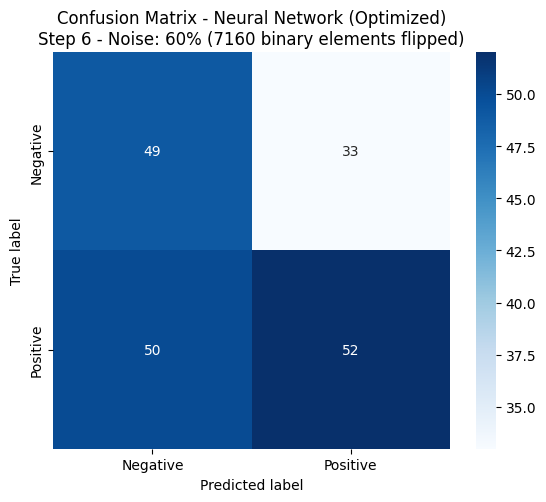

✅ Step 6 completed (Noise: 60%)


===== Training Neural Network (Optimized) at Step 7 (Noise: 70%) =====
Generated dataset with 70% noise (8353 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0151
Training Neural Network with Optimized approach...
Training completed in 5.9166 seconds
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 598us/step

RESULTS FOR STEP 7
  Binary elements flipped: 8353
  Accuracy Test:   0.3478
  Accuracy Train:  0.8978
  Precision:       0.4135
  Recall:          0.4216
  F1-score:        0.4175
  Training time:   5.9166 sec
  Val Accuracy:    0.3478
  Epochs completed: 100


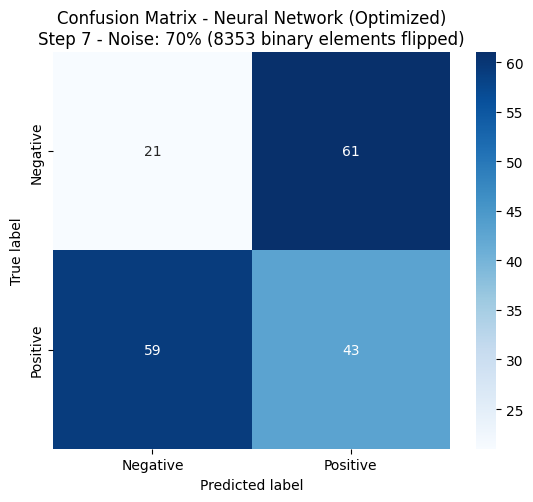

✅ Step 7 completed (Noise: 70%)


===== Training Neural Network (Optimized) at Step 8 (Noise: 80%) =====
Generated dataset with 80% noise (9547 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0266
Training Neural Network with Optimized approach...
Training completed in 6.5784 seconds
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 600us/step

RESULTS FOR STEP 8
  Binary elements flipped: 9547
  Accuracy Test:   0.3859
  Accuracy Train:  0.8965
  Precision:       0.4368
  Recall:          0.3725
  F1-score:        0.4021
  Training time:   6.5784 sec
  Val Accuracy:    0.3859
  Epochs completed: 100


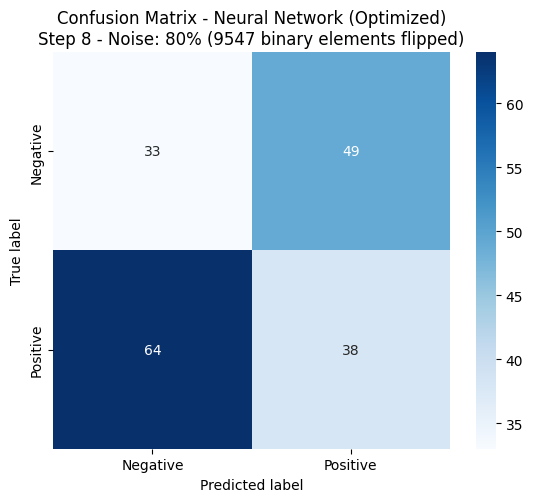

✅ Step 8 completed (Noise: 80%)


===== Training Neural Network (Optimized) at Step 9 (Noise: 90%) =====
Generated dataset with 90% noise (10740 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0426
Training Neural Network with Optimized approach...
Training completed in 7.4254 seconds
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 757us/step

RESULTS FOR STEP 9
  Binary elements flipped: 10740
  Accuracy Test:   0.2174
  Accuracy Train:  0.9155
  Precision:       0.2162
  Recall:          0.1569
  F1-score:        0.1818
  Training time:   7.4254 sec
  Val Accuracy:    0.2174
  Epochs completed: 100


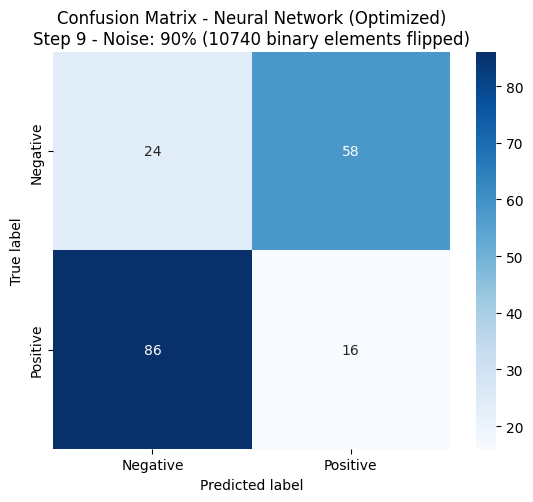

✅ Step 9 completed (Noise: 90%)


===== Training Neural Network (Optimized) at Step 10 (Noise: 100%) =====
Generated dataset with 100% noise (11934 binary elements flipped).
Training set size: 734 samples
Test set size: 184 samples
Mutual Information - Numerical features: 0.0590
Mutual Information - Binary features: 0.0644
Training Neural Network with Optimized approach...
Training completed in 6.2588 seconds
6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 585us/step

RESULTS FOR STEP 10
  Binary elements flipped: 11934
  Accuracy Test:   0.2120
  Accuracy Train:  0.9183
  Precision:       0.1884
  Recall:          0.1275
  F1-score:        0.1520
  Training time:   6.2588 sec
  Val Accuracy:    0.2120
  Epochs completed: 100


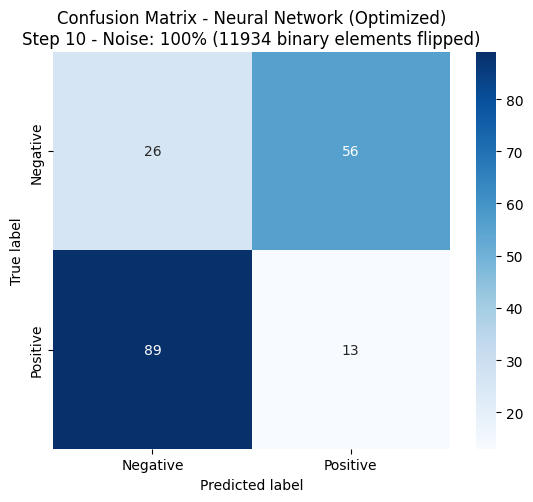

✅ Step 10 completed (Noise: 100%)


TRAINING COMPLETATO PER TUTTI I MODELLI


In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import SimpleImputer, KNNImputer, IterativeImputer
from sklearn.feature_selection import mutual_info_classif
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import joblib
from sklearn.pipeline import make_pipeline
import random
import os
from sklearn.compose import ColumnTransformer
from tensorflow.keras.losses import BinaryCrossentropy
from tensorflow.keras import optimizers


feature_importances = {}
confusion_matrix_values = {}

# Carica i modelli ottimizzati (se già salvati)
best_dt_params = joblib.load('best_decision_tree_model.pkl')
best_svm_params = joblib.load('best_svm_model.pkl')

svm_model = make_pipeline(
    ColumnTransformer([
        ('num', StandardScaler(), continuous_features),
        ('cat', 'passthrough', binary_features)
    ]),
    svm.SVC(random_state=42, probability=True) 
)

svm_optimized = make_pipeline(
    ColumnTransformer([
        ('num', StandardScaler(), continuous_features),
        ('cat', 'passthrough', binary_features)
    ]),
    svm.SVC(**best_svm_params, random_state=42)
)

# Parametri ottimizzati per il modello di deep learning personalizzato
best_nn_params = {
    'activation': 'relu',
    'batch_size': 32,
    'dropout_rate': 0.3,
    'random_state': 42,
    'epochs': 100,
    'hidden_layer_sizes': (100,),
    'optimizer': 'adam',
    'verbose': 0
}

# Split del dataset originale per ottenere il test set pulito
X_original = df.drop('HeartDisease', axis=1)
y_original = df['HeartDisease']

X_temp, X_test_clean, y_temp, y_test_clean = train_test_split(
    X_original, y_original, test_size=0.2, random_state=42, stratify=y_original
)

# Inizializzazione delle liste e dizionari per le metriche
timing_collector_noisy = {}
all_metrics_noisy = []
mutua_informazione_feature = []

class CustomNeuralNetworkNoise:
    """
    Classe wrapper per modello di deep learning personalizzato
    ottimizzata per gestire dati con rumore progressivo
    """
    
    def __init__(self, activation, batch_size, dropout_rate, 
                 epochs, hidden_layer_sizes, optimizer,
                 learning_rate, verbose,
                 random_state=42):
        
        # Imposta i semi per la riproducibilità
        tf.random.set_seed(random_state)
        np.random.seed(random_state)
        random.seed(random_state)
        os.environ['PYTHONHASHSEED'] = str(random_state)

        self.activation = activation
        self.batch_size = batch_size
        self.dropout_rate = dropout_rate
        self.epochs = epochs
        self.hidden_layer_sizes = hidden_layer_sizes
        self.optimizer = optimizer
        self.learning_rate = learning_rate
        self.verbose = verbose
        self.random_state = random_state
        self.model = None
        self.scaler = StandardScaler()
        self.history = None
        
    def _build_model(self, input_dim):
        
        model = Sequential()
        
        if len(self.hidden_layer_sizes) == 1:
            # Caso ottimizzato: (50,) → Dense(50) → Dense(1)
            model.add(Dense(self.hidden_layer_sizes[0], 
                           activation=self.activation, 
                           input_shape=(input_dim,)))
            model.add(Dropout(self.dropout_rate))
            model.add(Dense(1, activation='sigmoid'))    
            
        elif len(self.hidden_layer_sizes) == 2:
            # Caso naive: (100, 50) → Dense(100) → Dense(50) → Dense(1)
            model.add(Dense(self.hidden_layer_sizes[0], 
                           activation=self.activation, 
                           input_shape=(input_dim,)))
            model.add(Dense(self.hidden_layer_sizes[1], 
                           activation=self.activation))
            model.add(Dense(1, activation='sigmoid'))
        else:
            # Fallback generico
            model.add(Dense(self.hidden_layer_sizes[0], 
                           activation=self.activation, 
                           input_shape=(input_dim,)))
            
            for units in self.hidden_layer_sizes[1:]:
                model.add(Dense(units, activation=self.activation))
            
            model.add(Dense(1, activation='sigmoid'))
        
        # Compilazione
        selected_optimizer = optimizers.get(self.optimizer)
        model.compile(optimizer=selected_optimizer,
                    loss=BinaryCrossentropy(), 
                    metrics=['accuracy'])
        
        return model
    
    def fit(self, X, y, X_validation=None, y_validation=None):
        """
        Parameters:
        -----------
        X, y : training data
        X_validation, y_validation : validation data (se forniti, usa validation_data invece di validation_split)
        """
        # Normalizza solo le feature continue
        X_processed = X.copy()
        X_processed[continuous_features] = self.scaler.fit_transform(X[continuous_features])
        
        # Costruisce il modello
        input_dim = X_processed.shape[1]
        self.model = self._build_model(input_dim)
        
        # Preprocessa anche i dati di validazione se forniti
        if X_validation is not None and y_validation is not None:
            X_val_processed = X_validation.copy()
            X_val_processed[continuous_features] = self.scaler.transform(X_validation[continuous_features])
            validation_data = (X_val_processed, y_validation)
        else:
            validation_data = None
        
        if validation_data is not None:
            self.history = self.model.fit(
                X_processed, y,
                epochs=self.epochs,
                batch_size=self.batch_size,
                validation_data=validation_data,  
                verbose=self.verbose
            )
        else:
            # Fallback: senza validazione
            self.history = self.model.fit(
                X_processed, y,
                epochs=self.epochs,
                batch_size=self.batch_size,
                verbose=self.verbose
            )
        
        return self
    
    def predict(self, X):
        """Fa predizioni"""
        X_processed = X.copy()
        X_processed[continuous_features] = self.scaler.transform(X[continuous_features])
        
        predictions = self.model.predict(X_processed).ravel()  # .ravel() come primo codice
        return (predictions > 0.5).astype(int)
    
    def predict_proba(self, X):
        """Restituisce le probabilità predette"""
        X_processed = X.copy()
        X_processed[continuous_features] = self.scaler.transform(X[continuous_features])
        
        probabilities = self.model.predict(X_processed).ravel()
        return np.column_stack([1 - probabilities, probabilities])
    
    def score(self, X, y):
        """Calcola l'accuracy"""
        predictions = self.predict(X)
        return (predictions == y).mean()
    
def calculate_metrics(y_test, y_pred, model_name, approach_name, step_idx):
    """
    Calcola le metriche di valutazione
    """
    return {
        'model': model_name,
        'approach': approach_name,
        'step': step_idx,
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred, zero_division=0),
        'recall': recall_score(y_test, y_pred, zero_division=0),
        'f1_score': f1_score(y_test, y_pred, zero_division=0)
    }

def train_and_evaluate_model_with_binary_noise(
    df, target_column, X_test_clean, y_test_clean,
    model_class, model_params, model_name,
    approach_name, timing_collector, all_metrics_list,
    continuous_features, binary_features,
    mutua_informazione_feature=None,
    feature_importances=None
):
    """
    FIXED: Now adds noise to BINARY FEATURES instead of target labels
    """
    
    # Filter binary features to exclude target
    columns_to_noise = [col for col in binary_features if col != target_column]
    
    if len(columns_to_noise) == 0:
        raise ValueError("No binary features to add noise to (all excluded or empty list).")
    
    print(f"Binary columns to modify: {columns_to_noise}")
    
    noisy_datasets = {}
    n_samples = len(df)
    total_binary_elements = len(df) * len(columns_to_noise)
    
    print(f"Original DataFrame with {n_samples} rows.")
    print(f"Total binary elements to consider: {total_binary_elements}")
    print(f"Generating progressively noisy datasets and training {model_name} ({approach_name})...\n")

    cm_key = f"{model_name} - {approach_name}"
    if cm_key not in confusion_matrix_values:
        confusion_matrix_values[cm_key] = {}
    
    # Iterate through noise percentages
    for step_idx, percentage in enumerate(range(0, 101, 10)):
        print(f"\n===== Training {model_name} ({approach_name}) at Step {step_idx} (Noise: {percentage}%) =====")
        
        # Always work on a clean copy
        df_noisy = df.copy()
        
        if percentage == 0:
            noise_key = '0%_noise'
            noisy_datasets[noise_key] = df_noisy
            n_to_flip = 0
            print(f"Generated dataset with 0% noise (no modifications).")
        else:
            # FIX: Add noise to BINARY FEATURES, not target labels
            n_to_flip = int(np.floor(total_binary_elements * (percentage / 100)))
            
            # Create list of all possible positions (row, column)
            all_positions = [(row_idx, col) for row_idx in df.index for col in columns_to_noise]
            
            # Randomly select positions to flip (use step_idx for different seeds)
            np.random.seed(42 + step_idx)
            positions_to_flip = np.random.choice(len(all_positions), size=n_to_flip, replace=False)
            
            # Flip values at selected positions
            for pos_idx in positions_to_flip:
                row_idx, col = all_positions[pos_idx]
                df_noisy.loc[row_idx, col] = 1 - df_noisy.loc[row_idx, col]
            
            noise_key = f'{percentage}%_noise'
            noisy_datasets[noise_key] = df_noisy
            print(f"Generated dataset with {percentage}% noise ({n_to_flip} binary elements flipped).")
        
        # Split contaminated dataset
        X_contaminated = df_noisy.drop(target_column, axis=1)
        y_contaminated = df_noisy[target_column]
        X_train, _, y_train, _ = train_test_split(
            X_contaminated, y_contaminated, test_size=0.2, random_state=42, stratify=y_contaminated
        )
        
        print(f"Training set size: {len(X_train)} samples")
        print(f"Test set size: {len(X_test_clean)} samples")
        
        # Create separate copies to avoid in-place modifications
        X_train_processed = X_train.copy()
        X_test_processed = X_test_clean.copy()
        
        # Mutual Information (always on original unscaled data)
        mi = mutual_info_classif(X_train, y_train, discrete_features='auto', random_state=42)
        mi_df = pd.DataFrame({
            "feature": X_train.columns,
            "mutual_info": mi
        })
        mi_numerical = mi_df[mi_df["feature"].isin(continuous_features)]["mutual_info"].mean()
        mi_binary = mi_df[mi_df["feature"].isin(binary_features)]["mutual_info"].mean()
        
        print(f"Mutual Information - Numerical features: {mi_numerical:.4f}")
        print(f"Mutual Information - Binary features: {mi_binary:.4f}")
        
        if mutua_informazione_feature is not None:
            mutua_informazione_feature.append({
                "MI_numerical": mi_numerical,
                "MI_binary": mi_binary,
                "perc_noise": f"{percentage}%",
                "noise_samples": n_to_flip,
                "model": model_name,
                "approach": approach_name,
                "step": step_idx
            })

        # MODEL-SPECIFIC PREPROCESSING
        print(f"Training {model_name} with {approach_name} approach...")
        
        if model_name == 'SVM':
            scaler = StandardScaler()
            X_train_processed[continuous_features] = scaler.fit_transform(X_train_processed[continuous_features])
            X_test_processed[continuous_features] = scaler.transform(X_test_processed[continuous_features])
            
            if approach_name == "Naive":
                model = SVC(**model_params)
            elif approach_name == "Optimized":
                optimized_params = {**best_svm_params}
                if 'random_state' in model_params:
                    optimized_params['random_state'] = model_params['random_state']
                model = SVC(**optimized_params)
            
        elif model_name == 'Neural Network':
            model = model_class(**model_params)
            
        else:
            if approach_name == "Naive":
                model = model_class(**model_params)
            elif approach_name == "Optimized":
                if model_name == 'Decision Tree':
                    optimized_params = {**best_dt_params}
                    if 'random_state' in model_params:
                        optimized_params['random_state'] = model_params['random_state']
                    model = model_class(**optimized_params)
                else:
                    model = model_class(**model_params)

        # TRAINING
        start_time = time.time()
        
        if model_name == 'Neural Network':
            model.fit(X_train, y_train, X_validation=X_test_clean, y_validation=y_test_clean)
        else:
            model.fit(X_train_processed, y_train)

        end_time = time.time()
        training_time = end_time - start_time
        
        print(f"Training completed in {training_time:.4f} seconds")
        
        # Timing
        timing_key = f"{model_name.lower().replace(' ', '_')}_{approach_name.lower()}_noise_training_step_{step_idx}"
        timing_collector[timing_key] = training_time
        
        # PREDICTIONS
        if model_name == 'Neural Network':
            y_pred = model.predict(X_test_clean)
            y_pred_train = model.predict(X_train)
        else:
            y_pred = model.predict(X_test_processed)
            y_pred_train = model.predict(X_train_processed)
        
        # Training accuracy
        accuracy_train = accuracy_score(y_train, y_pred_train)
        
        # Calculate metrics
        metrics = calculate_metrics(y_test_clean, y_pred, model_name, approach_name, step_idx)
        metrics['training_time'] = training_time
        metrics['train_accuracy'] = accuracy_train
        metrics['contamination_step'] = step_idx
        metrics['noise_percentage'] = percentage
        metrics['noise_samples'] = n_to_flip
        metrics['test_set_type'] = 'clean'
        
        all_metrics_list.append(metrics)
        
        # Print metrics
        print(f"\nRESULTS FOR STEP {step_idx}")
        print(f"  Binary elements flipped: {n_to_flip}")
        print(f"  Accuracy Test:   {metrics['accuracy']:.4f}")
        print(f"  Accuracy Train:  {accuracy_train:.4f}")
        print(f"  Precision:       {metrics['precision']:.4f}")
        print(f"  Recall:          {metrics['recall']:.4f}")
        print(f"  F1-score:        {metrics['f1_score']:.4f}")
        print(f"  Training time:   {training_time:.4f} sec")
        
        if hasattr(model, 'history') and model.history:
            if 'val_accuracy' in model.history.history:
                final_val_acc = model.history.history['val_accuracy'][-1]
                print(f"  Val Accuracy:    {final_val_acc:.4f}")
            epochs_completed = len(model.history.history['loss'])
            print(f"  Epochs completed: {epochs_completed}")
        
        # Confusion matrix
        cm = confusion_matrix(y_test_clean, y_pred)
        TN, FP, FN, TP = cm.ravel()
        confusion_matrix_values[cm_key][step_idx] = {
            'TN': int(TN),
            'FP': int(FP),
            'FN': int(FN),
            'TP': int(TP),
            'confusion_matrix': cm.tolist()
        }
        
        # Visualize confusion matrix
        plt.figure(figsize=(6,5))
        sns.heatmap(cm, square=True, annot=True, fmt='d', cbar=True,
                   xticklabels=['Negative', 'Positive'],
                   yticklabels=['Negative', 'Positive'],
                   cmap='Blues')
        plt.title(f"Confusion Matrix - {model_name} ({approach_name})\nStep {step_idx} - Noise: {percentage}% ({n_to_flip} binary elements flipped)")
        plt.ylabel('True label')
        plt.xlabel('Predicted label')
        plt.tight_layout()
        plt.show()

        # Feature importances
        key = f"{model_name} - {approach_name}"
        if model_name == 'Decision Tree':
            if key not in feature_importances:
                feature_importances[key] = {}
            feature_importances[key][step_idx] = model.feature_importances_
            print(f"Feature Importances: {model.feature_importances_}")
        
        print(f"✅ Step {step_idx} completed (Noise: {percentage}%)\n")
    
    return noisy_datasets


print("="*80)
print("PROGRESSIVE NOISE CONTAMINATION EXPERIMENT")
print("="*80)

# --- Decision Tree ---
print("\n\n--- INIZIO TRAINING: DECISION TREE ---")

# Decision Tree Naive
print("Training Decision Tree - Naive approach...")
noisy_datasets_dt_naive = train_and_evaluate_model_with_binary_noise(
    df=df, 
    target_column='HeartDisease',
    X_test_clean=X_test_clean, 
    y_test_clean=y_test_clean,
    model_class=DecisionTreeClassifier, 
    model_params={'random_state': 42},
    model_name='Decision Tree', 
    approach_name='Naive',
    timing_collector=timing_collector_noisy, 
    all_metrics_list=all_metrics_noisy,
    continuous_features=continuous_features,
    binary_features=binary_features,
    mutua_informazione_feature=mutua_informazione_feature,
    feature_importances=feature_importances
)

# Decision Tree Optimized
print("Training Decision Tree - Optimized approach...")
noisy_datasets_dt_opt = train_and_evaluate_model_with_binary_noise(
    df=df, 
    target_column='HeartDisease',
    X_test_clean=X_test_clean, 
    y_test_clean=y_test_clean,
    model_class=DecisionTreeClassifier, 
    model_params={**best_dt_params, 'random_state': 42},
    model_name='Decision Tree', 
    approach_name='Optimized',
    timing_collector=timing_collector_noisy, 
    all_metrics_list=all_metrics_noisy,
    continuous_features=continuous_features,
    binary_features=binary_features,
    mutua_informazione_feature=mutua_informazione_feature,
    feature_importances=feature_importances
)

# --- Support Vector Machine (SVM) ---
print("\n\n--- INIZIO TRAINING: SVM ---")

# SVM Naive
print("Training SVM - Naive approach...")
noisy_datasets_svm_naive = train_and_evaluate_model_with_binary_noise(
    df=df, 
    target_column='HeartDisease',
    X_test_clean=X_test_clean, 
    y_test_clean=y_test_clean,
    model_class=SVC, 
    model_params={'random_state': 42},
    model_name='SVM', 
    approach_name='Naive',
    timing_collector=timing_collector_noisy, 
    all_metrics_list=all_metrics_noisy,
    continuous_features=continuous_features,
    binary_features=binary_features,
    mutua_informazione_feature=mutua_informazione_feature
)

# SVM Optimized
print("Training SVM - Optimized approach...")
noisy_datasets_svm_opt = train_and_evaluate_model_with_binary_noise(
    df=df, 
    target_column='HeartDisease',
    X_test_clean=X_test_clean, 
    y_test_clean=y_test_clean,
    model_class=SVC, 
    model_params={**best_svm_params, 'random_state': 42},
    model_name='SVM', 
    approach_name='Optimized',
    timing_collector=timing_collector_noisy, 
    all_metrics_list=all_metrics_noisy,
    continuous_features=continuous_features,
    binary_features=binary_features,
    mutua_informazione_feature=mutua_informazione_feature
)

# --- Neural Network con modello personalizzato ---
print("\n\n--- INIZIO TRAINING: NEURAL NETWORK (CUSTOM MODEL) ---")

# Neural Network Naive
print("Training Neural Network - Naive approach...")
noisy_datasets_nn_naive = train_and_evaluate_model_with_binary_noise(
    df=df, 
    target_column='HeartDisease',
    X_test_clean=X_test_clean, 
    y_test_clean=y_test_clean,
    model_class=CustomNeuralNetworkNoise, 
    model_params={
            'random_state': 42, 
            'epochs': 50, 
            'verbose': 0, 
            'batch_size': 32,
            'hidden_layer_sizes': (100, 50), 
            'learning_rate': 0.001,
            'activation': 'relu',
            'dropout_rate': 0.2,
            'optimizer': 'adam'
        },
    model_name='Neural Network', 
    approach_name='Naive',
    timing_collector=timing_collector_noisy, 
    all_metrics_list=all_metrics_noisy,
    continuous_features=continuous_features,
    binary_features=binary_features,
    mutua_informazione_feature=mutua_informazione_feature
)

# Neural Network Optimized
print("Training Neural Network - Optimized approach...")
noisy_datasets_nn_opt = train_and_evaluate_model_with_binary_noise(
    df=df, 
    target_column='HeartDisease',
    X_test_clean=X_test_clean, 
    y_test_clean=y_test_clean,
    model_class=CustomNeuralNetworkNoise, 
    model_params={**best_nn_params,'learning_rate': 0.001, 'random_state': 42},
    model_name='Neural Network', 
    approach_name='Optimized',
    timing_collector=timing_collector_noisy, 
    all_metrics_list=all_metrics_noisy,
    continuous_features=continuous_features,
    binary_features=binary_features,
    mutua_informazione_feature=mutua_informazione_feature
)

print("\n" + "="*80)
print("TRAINING COMPLETATO PER TUTTI I MODELLI")
print("="*80)

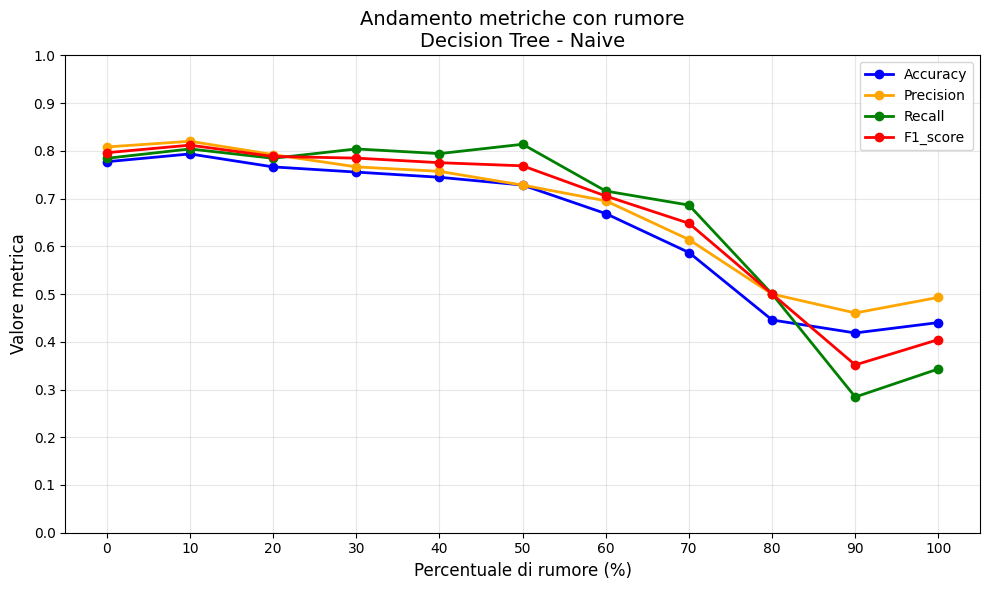

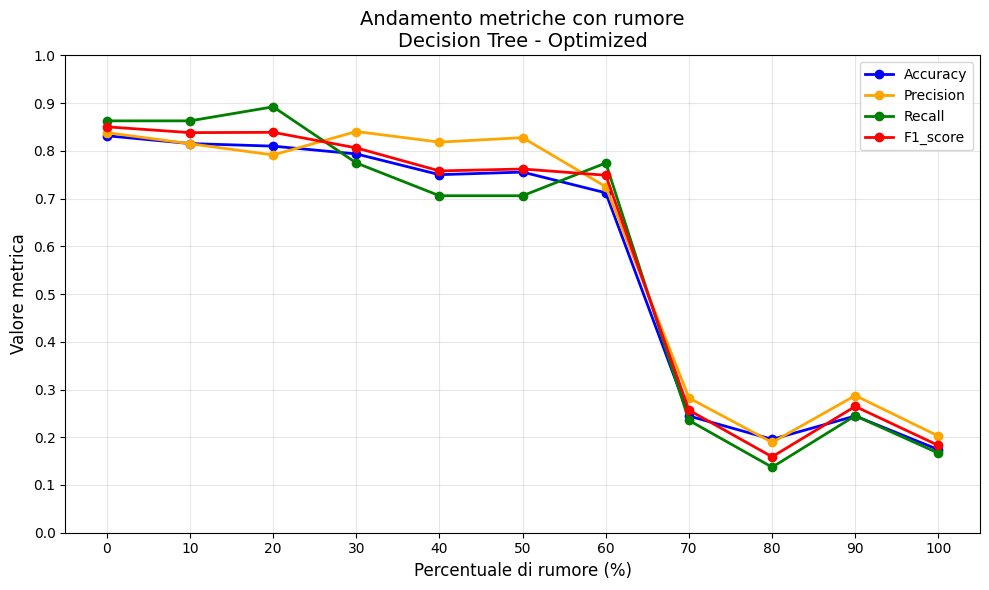

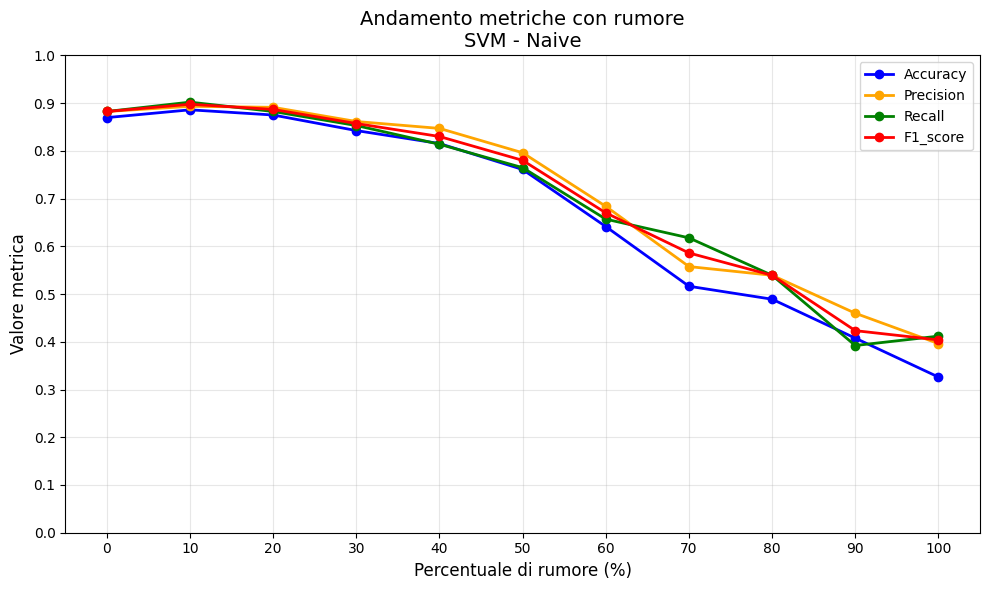

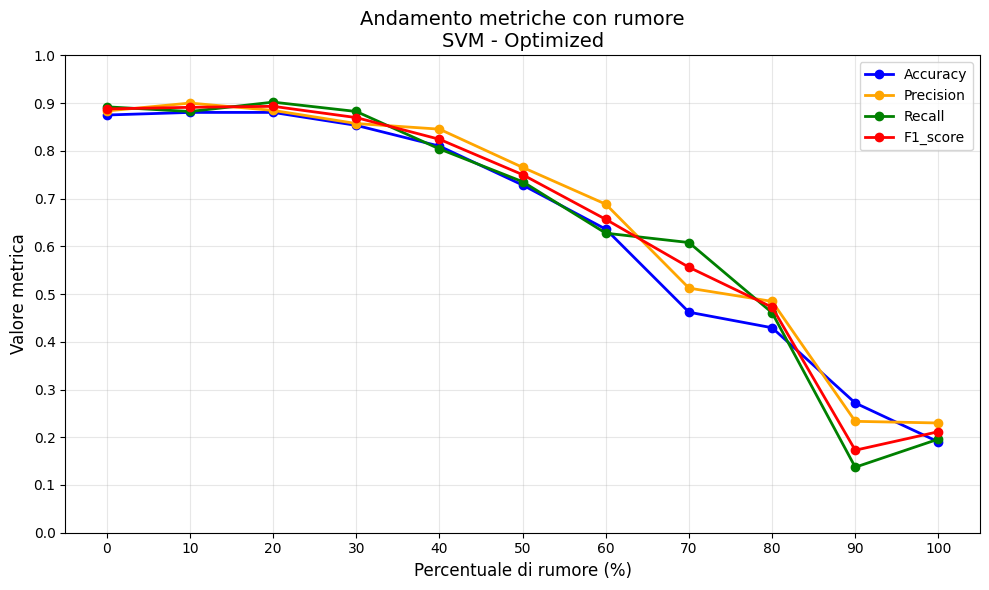

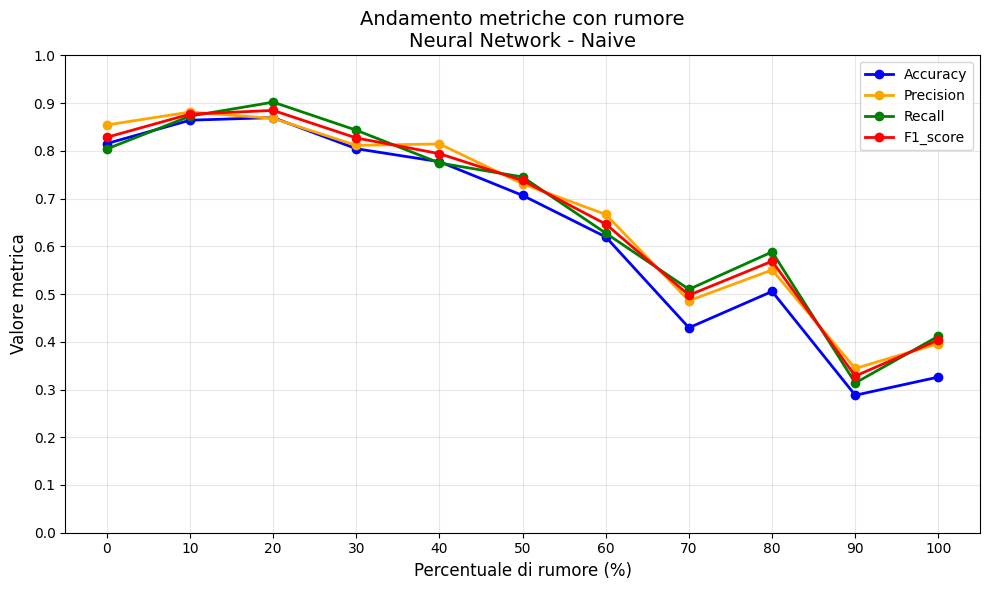

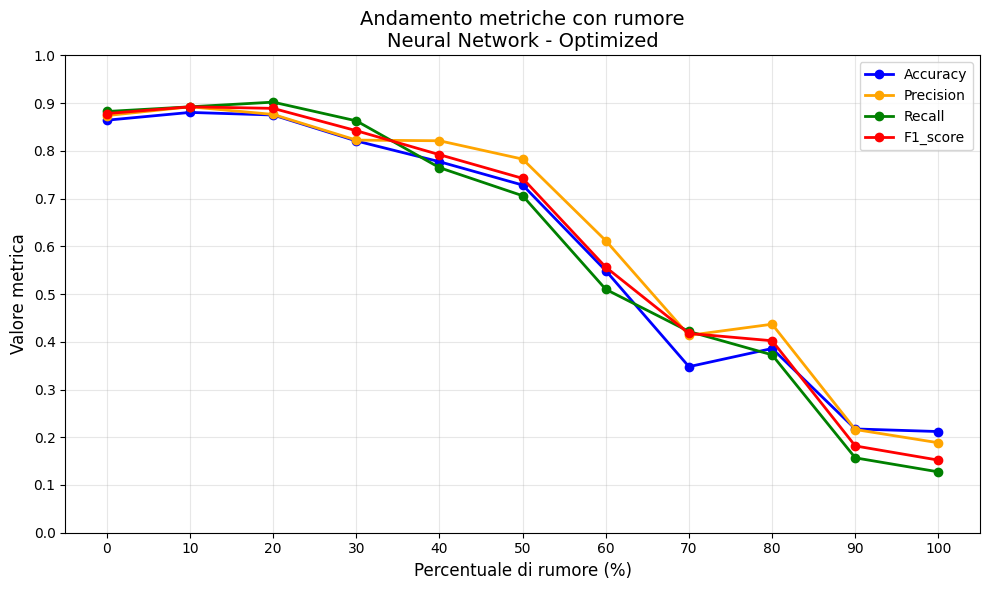

In [35]:
def plot_metrics_by_noise(all_metrics_noisy, noisy_datasets, model_name, approach, figsize=(10, 6)):
    """
    Crea un grafico unico che mostra Accuracy, Precision, Recall e F1-score
    al crescere della percentuale di rumore per un dato modello e approccio,
    includendo il dataset pulito (0% rumore).
    
    Args:
        all_metrics_noisy: lista di metriche calcolate sui dataset rumorosi
        noisy_datasets: dizionario di DataFrame con valori rumorosi
        original_df: DataFrame originale pulito (senza rumore)
        model_name: nome del modello da plottare
        approach: 'Naive' o 'Optimized'
        figsize: dimensione del grafico
    """
    # Estrai le percentuali di rumore dai nomi dei dataset
    noise_percentages = []
    for key in noisy_datasets.keys():
        if key == '0%_noise':
            noise_percentages.append(0)
        else:
            # Estrai la percentuale dal nome (es: '10%_noise' -> 10)
            noise_percentages.append(int(key.split('%')[0]))
    
    # Ordina le percentuali
    noise_percentages.sort()
    
    # Filtriamo per modello e approccio
    filtered_metrics = []
    for metrics in all_metrics_noisy:
        if metrics["model"] == model_name and metrics["approach"] == approach:
            # Trova il dataset corrispondente al passo
            step = metrics['step']
            noise_percentage = metrics.get('noise_percentage', step)
            #noise_percentage = noise_percentages[step]
            metrics_copy = metrics.copy()
            metrics_copy['noise_percentage'] = noise_percentage
            filtered_metrics.append(metrics_copy)
    
    if not filtered_metrics:
        print(f"Nessun dato trovato per {model_name} ({approach})")
        return
    
    # Crea DataFrame
    metrics_df = pd.DataFrame(filtered_metrics)
    metrics_df = metrics_df.sort_values("noise_percentage")
    
    # Metriche da plottare
    metric_names = ['accuracy', 'precision', 'recall', 'f1_score']
    colors = ['blue', 'orange', 'green', 'red']
    
    plt.figure(figsize=figsize)
    
    for metric, color in zip(metric_names, colors):
        plt.plot(metrics_df["noise_percentage"], metrics_df[metric],
                 marker='o', linewidth=2, markersize=6, color=color, label=metric.capitalize())

    plt.xlabel("Percentuale di rumore (%)", fontsize=12)
    plt.ylabel("Valore metrica", fontsize=12)
    plt.title(f"Andamento metriche con rumore\n{model_name} - {approach}", fontsize=14)
    plt.yticks(np.arange(0, 1.1, 0.1))
    plt.xticks(np.arange(0, 101, 10))
    plt.grid(True, alpha=0.3)
    plt.legend(fontsize=10)
    plt.tight_layout()
    plt.show()

# Esempi di utilizzo
plot_metrics_by_noise(all_metrics_noisy, noisy_datasets, 'Decision Tree', approach='Naive')
plot_metrics_by_noise(all_metrics_noisy, noisy_datasets, 'Decision Tree', approach='Optimized')
plot_metrics_by_noise(all_metrics_noisy, noisy_datasets, 'SVM', approach='Naive')
plot_metrics_by_noise(all_metrics_noisy, noisy_datasets, 'SVM', approach='Optimized')
plot_metrics_by_noise(all_metrics_noisy, noisy_datasets, 'Neural Network', approach='Naive')
plot_metrics_by_noise(all_metrics_noisy, noisy_datasets, 'Neural Network', approach='Optimized')

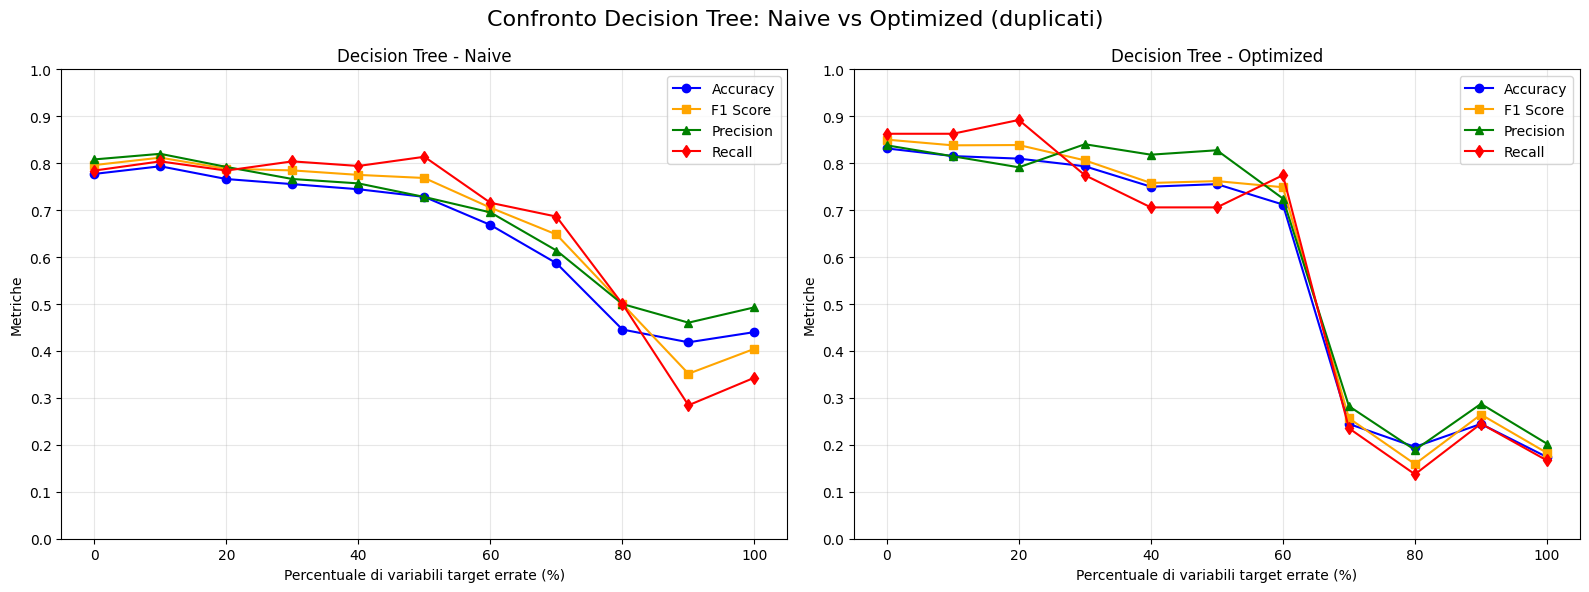

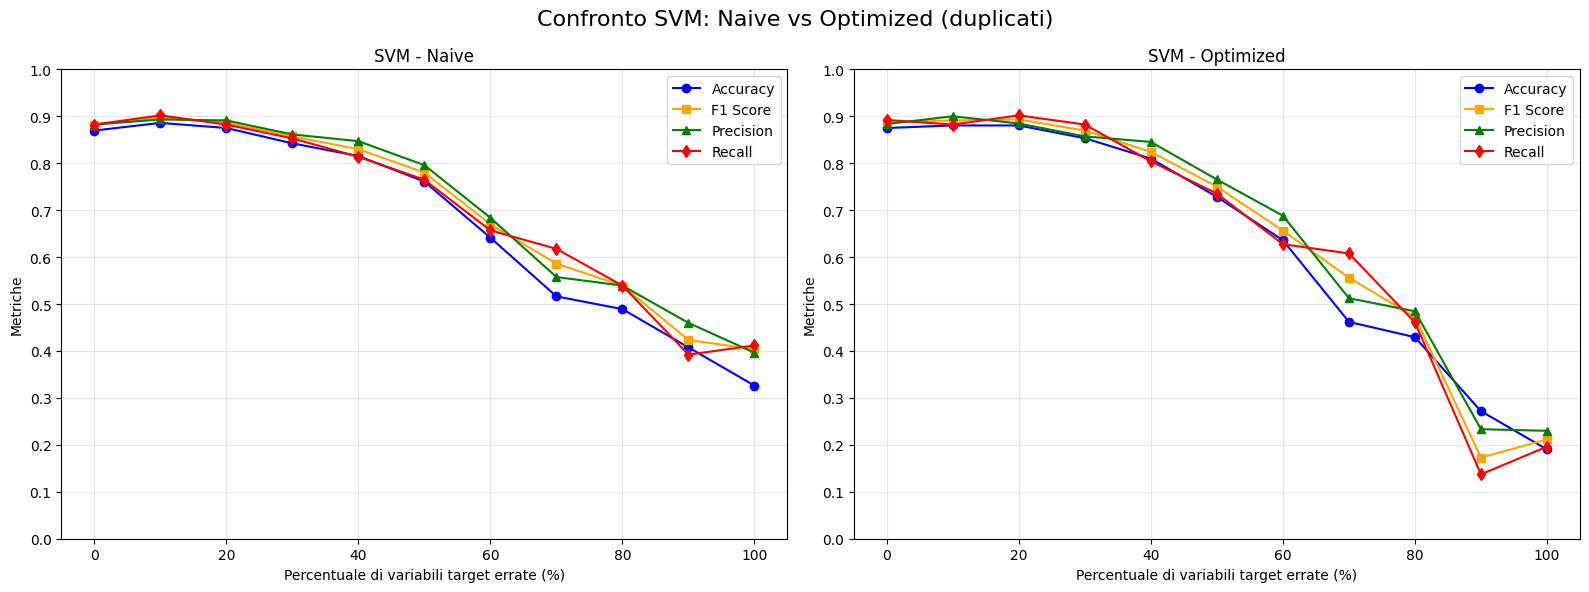

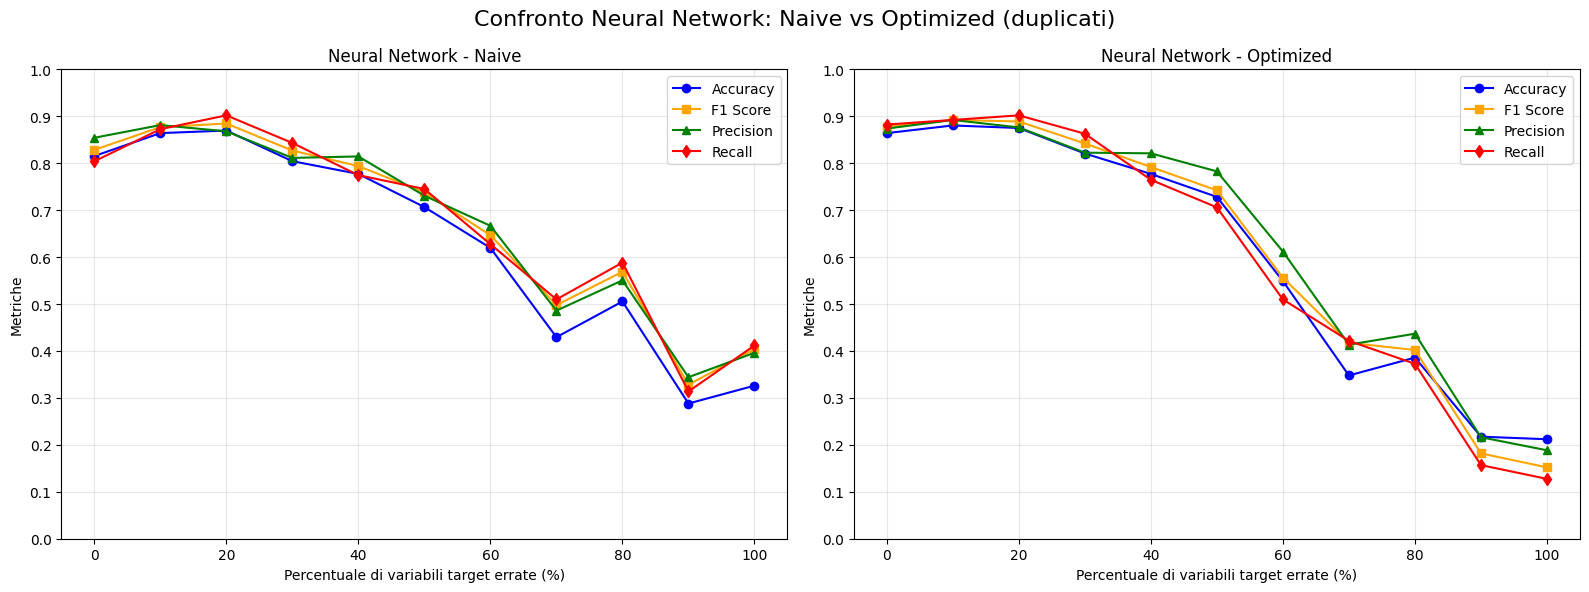

In [36]:
def plot_naive_vs_optimized_noisy(model_name, original_df):
    """
    Confronta approccio Naive vs Optimized per un modello con dataset contenenti rumore.
    
    Args:
        model_name: nome del modello da plottare
        duplicated_datasets: lista di DataFrame con duplicati
        original_df: dataset originale pulito
    """
    
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    
    for i, approach in enumerate(['Naive', 'Optimized']):
        metrics_df = pd.DataFrame(all_metrics_noisy)
        
        # Filtriamo per modello e approccio
        filtered_df = metrics_df[
            (metrics_df["approach"] == approach) &
            (metrics_df["model"] == model_name)
        ].sort_values("noise_percentage")
        
        if filtered_df.empty:
            print(f"Nessun dato trovato per {model_name} ({approach})")
            continue
        
        # Aggiungiamo il caso pulito (0% duplicati) se non presente
        if not (filtered_df['noise_percentage'] == 0).any():
            clean_row = filtered_df.iloc[0].copy()
            clean_row['noise_percentage'] = 0
            filtered_df = pd.concat([pd.DataFrame([clean_row]), filtered_df], ignore_index=True)
        
        # Plot metriche
        axes[i].plot(filtered_df["noise_percentage"], filtered_df["accuracy"], 
                     marker='o', color='blue', label="Accuracy")
        axes[i].plot(filtered_df["noise_percentage"], filtered_df["f1_score"], 
                     marker='s', color='orange', label="F1 Score")
        axes[i].plot(filtered_df["noise_percentage"], filtered_df["precision"], 
                     marker='^', color='green', label="Precision")
        axes[i].plot(filtered_df["noise_percentage"], filtered_df["recall"], 
                     marker='d', color='red', label="Recall")
        
        axes[i].set_xlabel("Percentuale di variabili target errate (%)")
        axes[i].set_ylabel("Metriche")
        axes[i].set_title(f"{model_name} - {approach}")
        axes[i].set_yticks(np.arange(0, 1.1, 0.1))
        axes[i].grid(True, alpha=0.3)
        axes[i].legend()
    
    plt.suptitle(f"Confronto {model_name}: Naive vs Optimized (duplicati)", fontsize=16)
    plt.tight_layout()
    plt.show()


plot_naive_vs_optimized_noisy('Decision Tree', df)
plot_naive_vs_optimized_noisy('SVM', df)
plot_naive_vs_optimized_noisy('Neural Network', df)


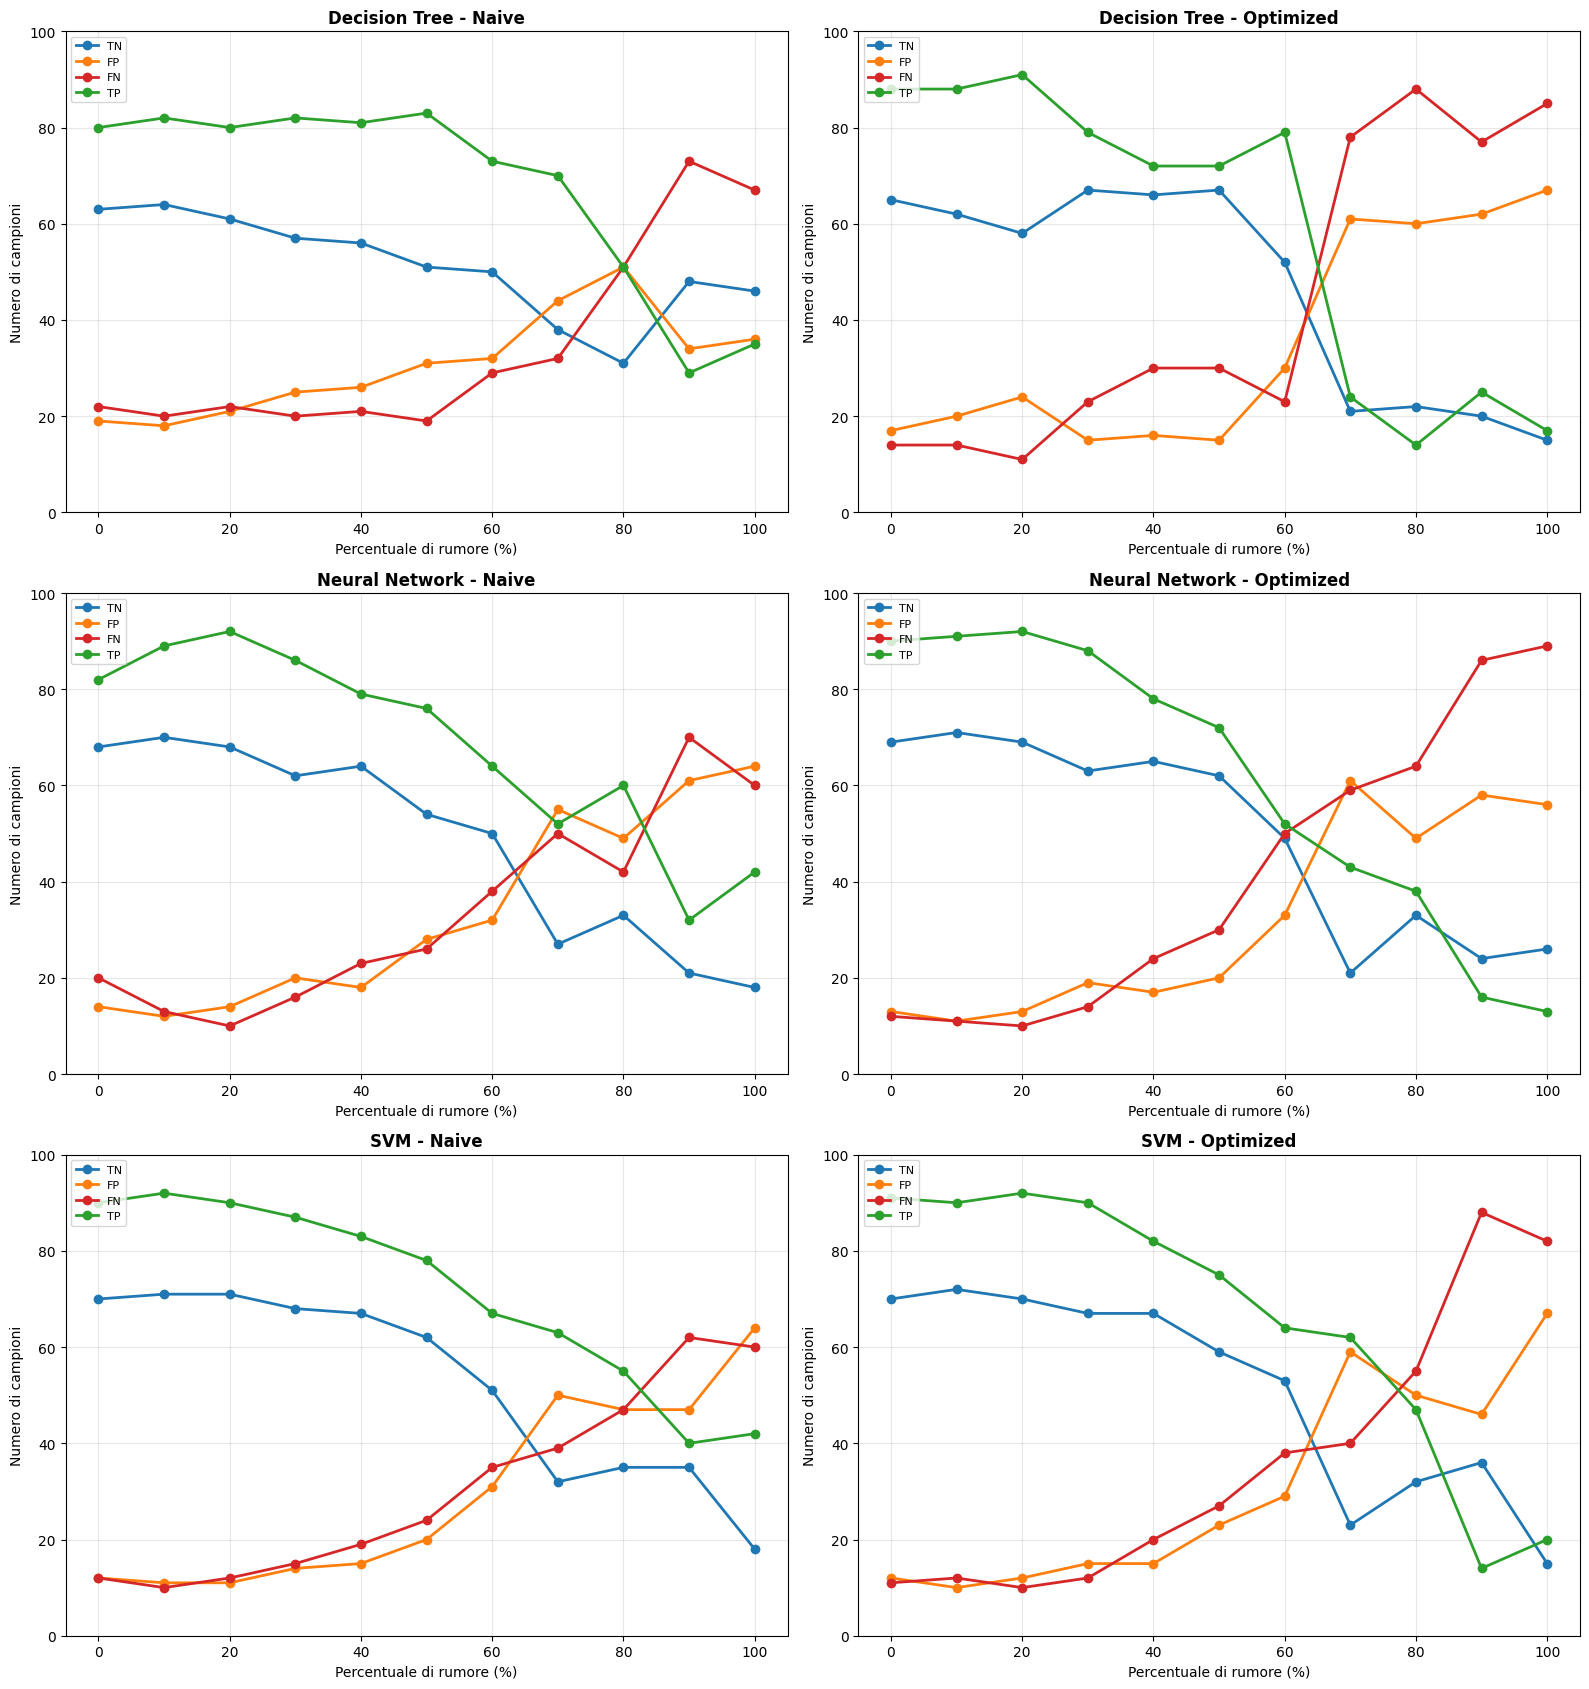

In [43]:
def plot_confusion_matrix_grid(confusion_matrix_values, noisy_datasets=None):
    """
    Crea una griglia di grafici 2 colonne x N righe (Naive | Optimized per modello)
    
    Parameters:
    -----------
    confusion_matrix_values : dict
        Dizionario con i valori delle confusion matrix
    contamination_history : list, optional
        Storia della contaminazione con step e actual_rate (default: usa step numerici)
    """
    
    # Estrai tutti i modelli unici (DT, SVM, NN)
    models = sorted(set(key.split(' - ')[0] for key in confusion_matrix_values.keys()))
    
    # Setup subplot: 2 colonne (Naive, Optimized), righe = numero modelli
    fig, axes = plt.subplots(len(models), 2, figsize=(16, 17))
    
    # Se c'è solo un modello, axes diventa 1D → forzo 2D
    if len(models) == 1:
        axes = [axes]
    
    colors = {
        'TN': '#1f77b4',  # blu
        'FP': '#ff7f0e',  # arancione  
        'FN': '#d62728',  # rosso
        'TP': '#2ca02c'   # verde
    }
    
    for model_idx, model in enumerate(models):
        for col_idx, approach in enumerate(["Naive", "Optimized"]):
            ax = axes[model_idx][col_idx]
            
            # Trova la chiave corretta (es: "Decision Tree - Naive")
            model_key = f"{model} - {approach}"
            if model_key not in confusion_matrix_values:
                continue
            
            # Estrai gli step
            steps = sorted(confusion_matrix_values[model_key].keys())
            
            nsteps = len(noisy_datasets) if noisy_datasets is not None else (max(steps) + 1)
            x_values = [(s / (nsteps - 1)) * 100 for s in steps]
            x_label = "Percentuale di rumore (%)"
            
            # Estrai valori TN, FP, FN, TP
            metrics_data = {
                'TN': [confusion_matrix_values[model_key][step]['TN'] for step in steps],
                'FP': [confusion_matrix_values[model_key][step]['FP'] for step in steps],
                'FN': [confusion_matrix_values[model_key][step]['FN'] for step in steps],
                'TP': [confusion_matrix_values[model_key][step]['TP'] for step in steps]
            }
            
            # Plot linee
            for metric in ['TN', 'FP', 'FN', 'TP']:
                ax.plot(x_values, metrics_data[metric], 
                        color=colors[metric], 
                        marker='o',
                        linestyle='-',
                        label=metric,
                        linewidth=2,
                        markersize=6)
            
            # Personalizza subplot
            ax.set_title(f"{model} - {approach}", fontsize=12, fontweight='bold')
            ax.set_xlabel(x_label, fontsize=10)
            ax.set_ylabel("Numero di campioni", fontsize=10)
            ax.grid(True, alpha=0.3)
            ax.legend(fontsize=8, loc='upper left')
            
            all_values = [v for metric in metrics_data.values() for v in metric]
            ax.set_ylim(0,100)
    
    plt.tight_layout()
    plt.show()

# Usa la funzione corretta
plot_confusion_matrix_grid(confusion_matrix_values, noisy_datasets)

=== ANALISI DELL'IMPATTO DELLE FEATURE ===



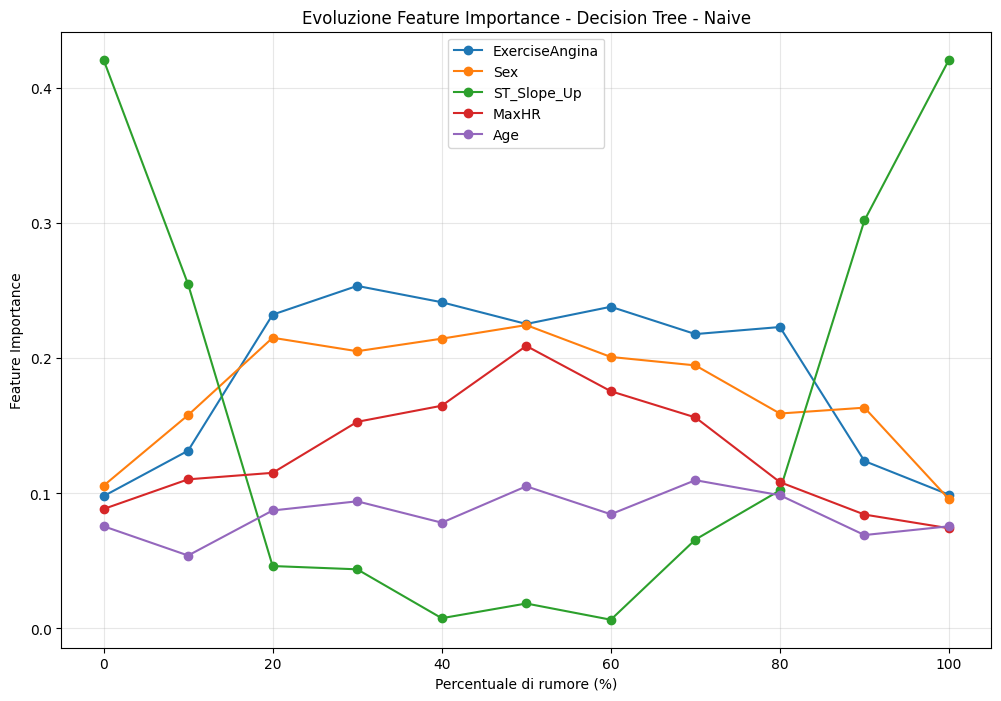


Decision Tree - Naive:
Media importanza feature continue: 0.0647
Media importanza feature binarie: 0.0520


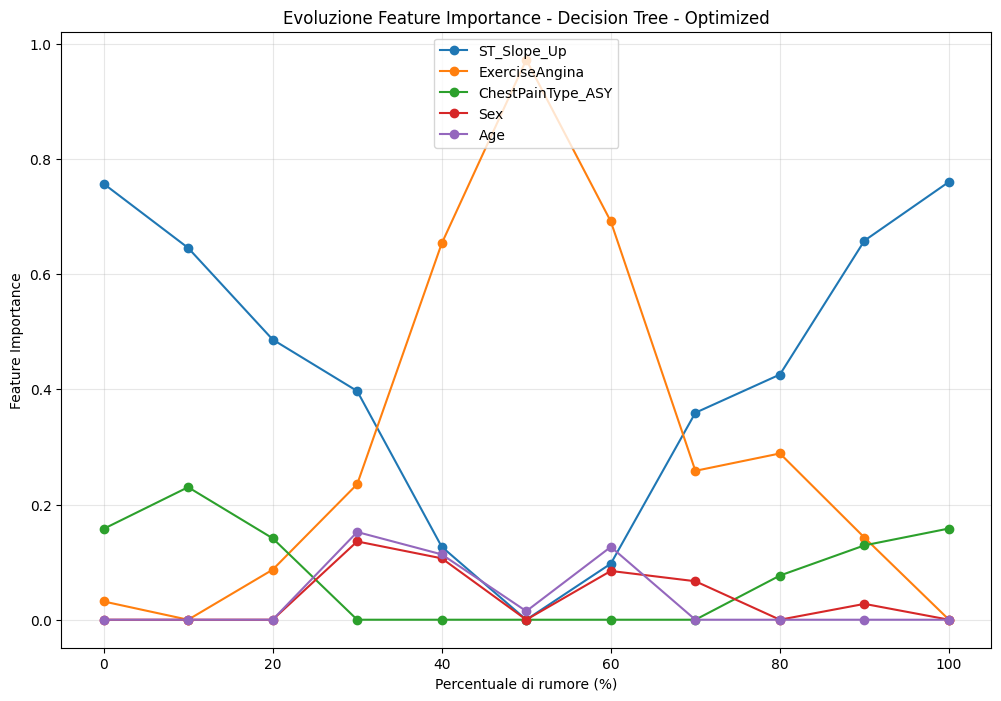


Decision Tree - Optimized:
Media importanza feature continue: 0.0162
Media importanza feature binarie: 0.0707


In [ ]:
# %%
# ANALISI AGGIUNTIVE PER IL PROGETTO MISSING VALUES

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.metrics import classification_report, roc_auc_score, roc_curve, confusion_matrix
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings('ignore')

# %%
# 5. ANALISI DELL'IMPATTO SPECIFICO DELLE FEATURE
def feature_impact_analysis(feature_importances, continuous_features, binary_features):
    """
    Analizza come l'importanza delle feature cambia con l'aumento dei missing values
    """

    # Rimuovi la target dalle liste se presente
    continuous_features = [f for f in continuous_features if f != 'HeartDisease']
    binary_features = [f for f in binary_features if f != 'HeartDisease']

    print("=== ANALISI DELL'IMPATTO DELLE FEATURE ===\n")
    
    if not feature_importances:
        print("Nessuna feature importance disponibile")
        return
    
    # Solo per Decision Tree che ha feature_importances
    for model_approach, step_importances in feature_importances.items():
        if 'Decision Tree' not in model_approach:
            continue
            
        # Crea DataFrame delle importanze per step
        importance_data = []
        for step, importances in step_importances.items():
            # Verifica che importances sia un array/lista valida
            if importances is not None and len(importances) > 0:
                for feat_idx, importance in enumerate(importances):
                    importance_data.append({
                        'step': step,
                        'feature_idx': feat_idx,
                        'importance': importance
                    })
        
        if not importance_data:
            continue
            
        importance_df = pd.DataFrame(importance_data)
        
        # Visualizza l'evoluzione delle top 5 feature più importanti
        plt.figure(figsize=(12, 8))
        
        # Trova le top feature basate sull'importanza media
        avg_importance = importance_df.groupby('feature_idx')['importance'].mean().sort_values(ascending=False)
        top_features = avg_importance.head(5).index
        
        for feat_idx in top_features:
            feat_data = importance_df[importance_df['feature_idx'] == feat_idx].sort_values('step')
            # Ottieni il nome della feature corrispondente all'indice
            if feat_idx < len(continuous_features):
                feat_name = continuous_features[feat_idx]
            elif feat_idx < len(continuous_features) + len(binary_features):
                feat_name = binary_features[feat_idx - len(continuous_features)]
            else:
                feat_name = f"Feature {feat_idx}"
            plt.plot(feat_data['step']*10, feat_data['importance'], 
                    marker='o', label=feat_name)
        
        plt.xlabel('Percentuale di rumore (%)')
        plt.ylabel('Feature Importance')
        plt.title(f'Evoluzione Feature Importance - {model_approach}')
        plt.legend(loc ='upper center')
        plt.grid(True, alpha=0.3)
        plt.show()
        
        # Analisi separata per feature continue vs binarie (se hai i nomi delle feature)
        print(f"\n{model_approach}:")
        
        # Verifica che gli indici esistano prima di accedervi
        continuous_indices = [i for i in range(len(continuous_features)) if i in avg_importance.index]
        binary_start = len(continuous_features)
        binary_end = len(continuous_features) + len(binary_features)
        binary_indices = [i for i in range(binary_start, binary_end) if i in avg_importance.index]
        
        if continuous_indices:
            print(f"Media importanza feature continue: {avg_importance[continuous_indices].mean():.4f}")
        else:
            print("Nessuna feature continua trovata negli indici")
            
        if binary_indices:
            print(f"Media importanza feature binarie: {avg_importance[binary_indices].mean():.4f}")
        else:
            print("Nessuna feature binaria trovata negli indici")

# Esegui l'analisi comprehensive:
comprehensive_results = feature_impact_analysis(feature_importances, continuous_features, binary_features)

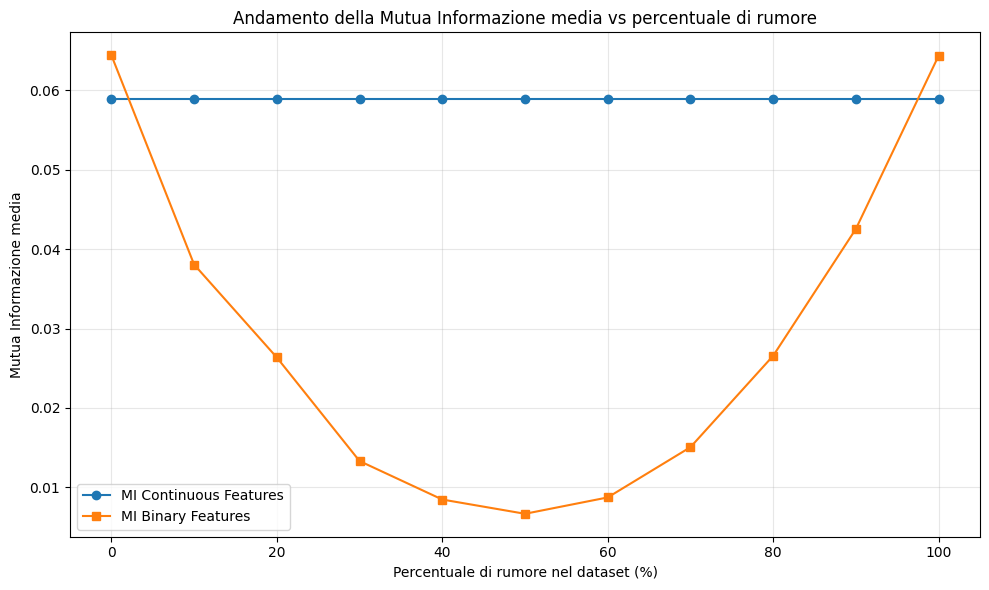

Primi righe del DataFrame dei risultati:
   MI_numerical  MI_binary perc_noise  noise_samples          model approach  \
0      0.058973   0.064428         0%              0  Decision Tree    Naive   
1      0.058973   0.038061        10%           1193  Decision Tree    Naive   
2      0.058973   0.026353        20%           2386  Decision Tree    Naive   
3      0.058973   0.013306        30%           3580  Decision Tree    Naive   
4      0.058973   0.008458        40%           4773  Decision Tree    Naive   

   step  noise_percentage  
0     0               0.0  
1     1              10.0  
2     2              20.0  
3     3              30.0  
4     4              40.0  

Colonne disponibili: ['MI_numerical', 'MI_binary', 'perc_noise', 'noise_samples', 'model', 'approach', 'step', 'noise_percentage']

Numero totale di records: 66

Statistiche MI per step:
    noise_percentage  MI_numerical  MI_binary
0                0.0      0.058973   0.064428
1               10.0      0.05

In [39]:
# Trasformiamo mutua_informazione_feature in DataFrame
df_results = pd.DataFrame(mutua_informazione_feature)

# Convertiamo la percentuale da stringa a float
# Nota: il campo si chiama "perc_noise" non "noise_percentage"
df_results["noise_percentage"] = df_results["perc_noise"].str.rstrip('%').astype(float)

# Raggruppiamo per percentuale di rumore e calcoliamo la media
df_grouped = df_results.groupby("noise_percentage")[["MI_numerical", "MI_binary"]].mean().reset_index()

# Plotting
plt.figure(figsize=(10, 6))
plt.plot(df_grouped["noise_percentage"], df_grouped["MI_numerical"], marker='o', label="MI Continuous Features")
plt.plot(df_grouped["noise_percentage"], df_grouped["MI_binary"], marker='s', label="MI Binary Features")
plt.xlabel("Percentuale di rumore nel dataset (%)")
plt.ylabel("Mutua Informazione media")
plt.title("Andamento della Mutua Informazione media vs percentuale di rumore")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Opzionale: stampa del DataFrame per debug
print("Primi righe del DataFrame dei risultati:")
print(df_results.head())
print(f"\nColonne disponibili: {df_results.columns.tolist()}")
print(f"\nNumero totale di records: {len(df_results)}")

# Opzionale: visualizza statistiche per step
print("\nStatistiche MI per step:")
print(df_grouped)